## Checking GPU on Mac

## Using Tensorflow and Diagnosis of the Performance and Optimization of the model

In [1]:
import tensorflow as tf
from tensorflow.python.profiler import profiler_v2 as profiler
import time
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

In [2]:
# List physical devices available
gpus = tf.config.list_physical_devices('GPU')

# Print the number of GPUs detected
print(f"Number of GPUs available: {len(gpus)}")

# Optional: print detailed info about each GPU
for gpu in gpus:
    print(gpu)

Number of GPUs available: 1
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# import tensorflow as tf

# # Specify the directory to save the profiling data
# logdir = 'profiler_logs'

# # Start profiling
# tf.profiler.experimental.start(logdir)

# # Run your TensorFlow code
# with tf.device('/GPU:0'):
#     a = tf.constant([[1.0, 2.0, 3.0]])
#     b = tf.constant([[1.0], [2.0], [3.0]])
#     result = tf.matmul(a, b)
#     print(result)

# # Stop profiling
# tf.profiler.experimental.stop()

In [4]:
# Load TensorBoard to visualize the profiling results
%load_ext tensorboard

In [5]:
# %tensorboard --logdir=profiler_logs

## Using GPU T4 from Kaggle

The T4 GPU provided by Kaggle is well-suited for most deep learning tasks, offering a balance between performance and energy efficiency. It is particularly good for inference and small-to-moderate training jobs.

The T4 GPU in Kaggle has 16 GB of GPU memory, which is enough for training many types of models (e.g., CNNs, transformers). However, for very large datasets or complex models, memory might become a limiting factor.


# Spatial Photonic Ising Machine By Spatial Light Modulation

A spatial light modulator (SLM) is a device that can manipulate the phase, amplitude, or polarization of a light beam spatially. In other words, it can control the properties of light pixel by pixel across its surface. The SLM then applies the corresponding phase shift to each pixel based on the desired spin configuration.

SLMs can modulate the phase of light by controlling the thickness of a liquid crystal layer pixel by pixel. By applying different voltages to each pixel, the refractive index of the liquid crystal can be changed, altering the phase of the light passing through.


## Procedure

## Randomly Generate a Phase Matrix

In [6]:
def generate_random_phase_matrix(n):
    """
    Generates a random phase matrix of size nxn.
    """
    # Generate random phases (0 or π)
    phase_matrix = np.random.choice([0, np.pi], size=(n, n))
    return phase_matrix

### 1. Encoding spin variables: 

The phase encoding of spins using binary values $\sigma_j = e^{\phi_j} = \pm 1$, where $\phi_j \in \{0,\pi\}$
Convert binary spin values (+1, -1) into phase
modulations of a light field using a spatial light modulator.

$\begin{aligned}
\begin{bmatrix}
0 & 0 & \pi & 0 \\
\pi & 0 & 0 & \pi \\
0 & \pi & \pi & 0 \\
\pi & 0 & 0 & \pi
\end{bmatrix}
\end{aligned}
\hspace{1cm}
\rightarrow
\hspace{1cm}
\begin{bmatrix}
1 & 1 & -1 & 1 \\
-1 & 1 & 1 & -1 \\
1 & -1 & -1 & 1 \\
-1 & 1 & 1 & -1
\end{bmatrix}$

In [7]:
def binary_phase_to_spin(phase_matrix):
  """Converts a binary phase matrix to a spin variable matrix.
  """
  spin_matrix = np.where(phase_matrix == 0, 1, -1)
  return spin_matrix

In [8]:
def print_phase_matrix_in_pi(phase_matrix):
    """Prints the phase matrix with values displayed as '0' or 'π'."""
    phase_symbols = np.where(phase_matrix == 0, '0', 'π')
    
    # Convert the matrix to a readable string format
    for row in phase_symbols:
        print(' '.join(row))

In [9]:
# Example usage
phase_matrix = np.array([
  [0, 0, np.pi, 0],
  [np.pi, 0, 0, np.pi],
  [0, np.pi, np.pi, 0],
  [np.pi, 0, 0, np.pi]
])

In [10]:
spin_matrix = binary_phase_to_spin(phase_matrix)

In [11]:
print("Phase Matrix:")
print_phase_matrix_in_pi(phase_matrix)
print("Spin Matrix:")
print(spin_matrix)
print(f"The shape of the phase matrix is {phase_matrix.shape}.")
print(f"The size of the phase matrix is {phase_matrix.size}.")

Phase Matrix:
0 0 π 0
π 0 0 π
0 π π 0
π 0 0 π
Spin Matrix:
[[ 1  1 -1  1]
 [-1  1  1 -1]
 [ 1 -1 -1  1]
 [-1  1  1 -1]]
The shape of the phase matrix is (4, 4).
The size of the phase matrix is 16.


## Now contruct the Target spin matrix and the random spin matrix

In [12]:
n = 10  # You can adjust this to any value for nxn matrix

target_phase_matrix = generate_random_phase_matrix(n)
target_spin_matrix = binary_phase_to_spin(target_phase_matrix)

detected_phase_matrix = generate_random_phase_matrix(n)
detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)

In [13]:
print("Target Phase Matrix:\n")
print_phase_matrix_in_pi(target_phase_matrix)
print("Target Spin Matrix:")
print(target_spin_matrix)
print(f"The shape of the target phase matrix is {target_phase_matrix.shape}.")
print(f"The size of the target phase matrix is {target_phase_matrix.size}.")

print("Detected Random Phase Matrix:")
print_phase_matrix_in_pi(detected_phase_matrix)
print("Detected Random Spin Matrix:")
print(detected_spin_matrix)
print(f"The shape of the random spin matrix is {detected_spin_matrix.shape}.")
print(f"The size of the random spin matrix is {detected_spin_matrix.size}.")

# it determines the the number of pixels or elements in the spatial domain.

Target Phase Matrix:

0 π π π 0 π 0 π π 0
0 0 π 0 π 0 0 0 0 π
π 0 0 π π π 0 π 0 π
0 0 π π 0 0 0 π 0 0
0 0 π 0 π 0 π 0 π 0
0 π 0 0 0 0 0 0 0 0
0 π 0 0 π 0 π 0 π 0
π 0 0 π 0 0 0 0 π 0
0 0 0 0 π π π π π 0
π 0 0 π π π π π 0 π
Target Spin Matrix:
[[ 1 -1 -1 -1  1 -1  1 -1 -1  1]
 [ 1  1 -1  1 -1  1  1  1  1 -1]
 [-1  1  1 -1 -1 -1  1 -1  1 -1]
 [ 1  1 -1 -1  1  1  1 -1  1  1]
 [ 1  1 -1  1 -1  1 -1  1 -1  1]
 [ 1 -1  1  1  1  1  1  1  1  1]
 [ 1 -1  1  1 -1  1 -1  1 -1  1]
 [-1  1  1 -1  1  1  1  1 -1  1]
 [ 1  1  1  1 -1 -1 -1 -1 -1  1]
 [-1  1  1 -1 -1 -1 -1 -1  1 -1]]
The shape of the target phase matrix is (10, 10).
The size of the target phase matrix is 100.
Detected Random Phase Matrix:
π 0 π 0 π π π 0 π π
π π 0 π 0 0 0 π π 0
0 0 0 π π 0 0 π π 0
π 0 0 π π 0 π π π π
0 π 0 0 π 0 0 0 0 π
0 π π 0 π 0 0 0 π π
π 0 π 0 0 π 0 π π 0
0 π 0 π 0 π π 0 π 0
π π 0 π 0 π 0 π 0 0
π 0 0 π π π 0 0 0 π
Detected Random Spin Matrix:
[[-1  1 -1  1 -1 -1 -1  1 -1 -1]
 [-1 -1  1 -1  1  1  1 -1 -1  1]
 [ 1  1 

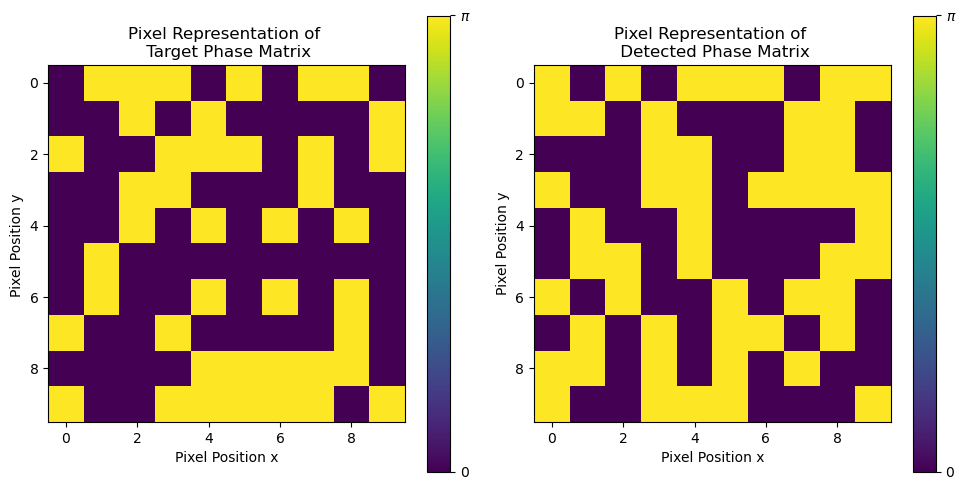

In [14]:
# Create the pixel-like image
# Create the plot
fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # gridspec_kw={'width_ratios': [1, 1.1]}

# Plot the spin matrix on the left
axes[0].imshow(target_phase_matrix, cmap='viridis')
axes[0].set_title("Pixel Representation of \n Target Phase Matrix")
axes[0].set_xlabel("Pixel Position x")
axes[0].set_ylabel("Pixel Position y ")

# Plot the random phase matrix on the right
cax = axes[1].imshow(detected_phase_matrix, cmap='viridis')
axes[1].set_title("Pixel Representation of \n Detected Phase Matrix")
axes[1].set_xlabel("Pixel Position x")
axes[1].set_ylabel("Pixel Position y")

# Add colorbar for the phase matrix plot
cbar1 = fig.colorbar(cax, ax=axes[0])
cbar2 = fig.colorbar(cax, ax=axes[1])

# Set the colorbar ticks and labels
cbar_ticks = [0, np.pi]
cbar_labels = ['0', '$\pi$']

cbar1.set_ticks(cbar_ticks)
cbar1.set_ticklabels(cbar_labels)

cbar2.set_ticks(cbar_ticks)
cbar2.set_ticklabels(cbar_labels)

# Show the plots
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/phase_matrices_comparison.png')  # Save as PNG file
plt.show()

In [15]:
print(f"Target phase matrix is \n{target_phase_matrix}.\n")
print(f"Detected phase matrix is \n {detected_phase_matrix}.")

Target phase matrix is 
[[0.         3.14159265 3.14159265 3.14159265 0.         3.14159265
  0.         3.14159265 3.14159265 0.        ]
 [0.         0.         3.14159265 0.         3.14159265 0.
  0.         0.         0.         3.14159265]
 [3.14159265 0.         0.         3.14159265 3.14159265 3.14159265
  0.         3.14159265 0.         3.14159265]
 [0.         0.         3.14159265 3.14159265 0.         0.
  0.         3.14159265 0.         0.        ]
 [0.         0.         3.14159265 0.         3.14159265 0.
  3.14159265 0.         3.14159265 0.        ]
 [0.         3.14159265 0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         3.14159265 0.         0.         3.14159265 0.
  3.14159265 0.         3.14159265 0.        ]
 [3.14159265 0.         0.         3.14159265 0.         0.
  0.         0.         3.14159265 0.        ]
 [0.         0.         0.         0.         3.14159265 3.14159265
  3.14159265 3.14159265 3.14159265 0

The above code only involves the phase values ($0$ and $\pi$) mapping to the spin variables, but this mapping effectively incorporates the exponential term. 
\begin{equation}
\sigma_j = e^{i\phi_j}
\end{equation}

It means that phase $\phi_j = 0$ corresponds to $\sigma_j e^{i \times 0}= 1$, hase $\phi_j = \pi$ corresponds to $\sigma_j e^{i \pi}= -1$. This completely represent the phases of the spin variables that maps the phases values to the spin variables: $0 \rightarrow 1$ and $\pi \rightarrow -1$.



### The experimental setup:
1. Continuous Laser source with wavelength $\lambda = 532nm$. 
2. Holoeye LC-R 720
3. resolution $1280 \times 768$ pixels
4. Pixel pitch $20 \times 20 \mu m$
5. Active area to host $N = L\times L$
6. foocal lens $f = 500mm$
7. Intensity is measure on $M = 18 \times 18$ spatial modes obtained grouping $16 \times 16$ camera pixels

Pixel pitch refers to the distance between the centers of adjacent pixels. If the pixels are square, this values represents both the width and the height of each pixel. From the given information on the paper, the pixel pitch of the SLM is $20 \times 20 \mu m$, which indicate the each pixel is a square with a side length of $20 \mu m$.

In the spatial domain, a rectangular function represents a finite-width window. The function can be described as follow: If the the domain is within the range of $x \in [-W, W]$ then it is $1$, otherwise it is $0$. This function models the finite size of a pixel because it is nonzero only within the pixel's extent and zero outside it.

In the frequency domain, the Fourier transform of the rectangular function in the spatial domain is a sinc function. The sinc function describes how the spatial domain's retangular function (the pixel's finite size) affects the ditribution of spatial frequencies. 

$W$ refers to the width of the rectangular function in the spatial domain. When the rectangular function is taken the Fourier transform, a sinc function in the frequency domain is obtained.

The normalized $\tilde{\delta}_W$ models the pixel of finite size 2W, so that 

\begin{equation}
k_j = 2Wj, \quad j = 1,2,3,...,n. 
\end{equation}

$2W$ represents the width of the pixel in the spatial domain. Since the pixel pitch is $20 \mu m$, the pixel width $2W$ would naturally be $20 \mu m$, assuming the pixels are fully utilized. 

We define `j_values` as a range from 1 to n. 

`j_values = np.arange(1, n+1)`

  `k_j = 2 * W * j`

The normalized sinc function is expressed as:

\begin{equation}
sinc{x} = \frac{\sin{}\pi x}{\pi x}
\end{equation}
 
The sinc function is centered at $k_j = 2Wj$, which means that its shape and position vary with the index `j`. This reflects the fact that each pixel contributes a different spatial frequency component to the overall electric field. The sinc function is introduced as expressed as follow:

\begin{equation}
\tilde{\delta_W}(k-k_j) = \frac{\sin{W(k-k_j)}}{W(k-k_j)}, \quad j = 1,2,3,...., n
\end{equation}

The sinc function $\sin{W(k-k_j)}$ models the pixel's finite size and its response in the spatial frequency domain. $W(k - k_j)$ determine the width of the sinc function, and hence the spatial localization of the electric field in the frequency domain. 

he larger the $W$ (indicating a larger pixel in the spatial domain), the narrower the sinc function in the spatial frequency domain. This indicates that the electric field is more concentrated in the spatial frequency domain, leading to a broader (less localized) distribution in the spatial domain. Conversely, a smaller $W$ results in a broader sinc function in the spatial frequency domain, which corresponds to a more localized (sharper) distribution in the spatial domain. $\tilde{\delta}_W(k - k_j)$ represents the Fourier transform of a rectangular sinc function, which corresponds to the finite size of the pixel in the spatial domain by describing how electric field being modulated by the finite size of the pixel in the Fourier domain. $k-k_j$ represents the spatial frequency difference between a particular frequency $k$ and the frequency $k_j$ associated with the pixel position. 
    
  `delta_w_k = np.sinc(W * (k - k_j))`

The `k` array represents the spatial frequency grid. Its length determines the number of frequency components considered. The specific values in the `k` array depend on the pixel pitch, the wavelength, and the desired spatial frequency range. The pixel pitch and wavelength of the light determine the spatial frequency bandwidth. The desired spatial resolution in the Fourier domain will influence the range of `k` values. 

To avoid aliasing, the maximum frequency in `k` should be at least twice the Nyquist frequency, which is determined by the pixel pitch and the wavelength. The Nyquist frequency, which represents the maximum resolvable spatial frequency. 

### 2. Light propagation: 

The function `calculate_spatial_frequency_grid` calculates the spatial frequency grid based on the pixel pitch, wavelength, and desired number of points. The idea is to create a grid that represents the spatial frequencies based on the Nyquist frequency and the specified factor. The `factor` parameter is to allow adjusting the range of k based on the specific requirements. A larger factor will result in a wider range of spatial frequencies being considered. The `num_points` parameter can be adjusted to control the resolution in the Fourier domain. The Nyquist frequency `nyquist_frequency` is a crucial factor in determining the appropriate range of `k` values. 

`k` should match the dimensions of the spatial domain grid corresponding to the phase matrix. A grid of spatial frequencies `kx` and `ky` is created using `np.meshgrid`.

"""Calculates the spatial frequency grid.
    Args:
        pixel_pitch: The pixel pitch.
        wavelength: The wavelength of the light.
        num_points: The number of points sampled in the spatial frequency domain, which is used to determined the resolution of the spatial frequency grid. The larger value means finer resolution.
        factor: A factor to determine the maximum frequency
    Returns:
        The spatial frequency grid as a NumPy array.
        Nyquist frequency: It represents half of the maximum frequency in the spatial frequency grid to avoid aliasing,
        which is determined by the pixel pitch and the wavelength.
    """
        """Calculates the spatial frequency grid.

    Args:
        pixel_pitch: The pixel pitch.
        wavelength: The wavelength of the light.
        num_points: The number of points sampled in the spatial frequency domain,
                   which is used to determined the resolution of the spatial frequency grid.
                   The larger value means finer resolution.
        factor: A factor to determine the maximum frequency (default: 2).

    Returns:
        The spatial frequency grid as a NumPy array.

        Nyquist frequency:
        It represents half of the maximum frequency in the spatial frequency grid to avoid aliasing,
        which is determined by the pixel pitch and the wavelength.
    """

In [16]:
# def calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points, factor = 1):
#     # Calculate the Nyquist frequency
#     nyquist_frequency = 1 / (2 * pixel_pitch)

#     # Determine the maximum frequency based on the factor
#     max_frequency = factor * nyquist_frequency

#     # Create the spatial frequency grid
#     k = np.linspace(-max_frequency, max_frequency, num_points)
#     kx, ky = np.meshgrid(k, k)  # Create a grid of kx, ky
#     return kx, ky

def calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points, factor=1):
    # Calculate the Nyquist frequency
    nyquist_frequency = 1 / (2 * pixel_pitch)

    # Determine the maximum frequency based on the factor
    max_frequency = factor * nyquist_frequency

    # Create the spatial frequency grid
    k = np.linspace(-max_frequency, max_frequency, num_points)
    kx, ky = np.meshgrid(k, k)  # Create a grid of kx, ky
    
    # Optionally apply a scaling factor based on the wavelength
    kx *= (2 * np.pi / wavelength)
    ky *= (2 * np.pi / wavelength)

    return kx, ky

`num_points` represents the number of spatial samples or grid points in each dimension of the simulation, which corresponds to the size of `target_spin_matrix`. The number of points is et by ht enumer of rows or columns (in our case it is a square matrix) in the `target_spin_matrix`. The matrix represents the form of pixelzated spin system, where each entry corresponds to the spin variable at a given point on the grid. The resolution of the simulation (number of points) should match the desired accuracy and the spatial extent of the system. 

In [17]:
xi = 1.0  # Scalar amplitude coefficient
pixel_pitch = 20e-6  # Pixel pitch in meters
W = pixel_pitch / 2  # Half of Pixel pitch
wavelength = 532e-9  # Wavelength in meters
num_points = target_spin_matrix.shape[0]
k = calculate_spatial_frequency_grid(pixel_pitch, wavelength, 100)

In [18]:
# print(k)
# print(k.shape)
# print(k.size)

The modulated light propagates through an optical system. Interactions between different light paths create interference patterns. When two or more light waves overlap, they interfere with each other. The resulting intensity depends on the phase difference between the waves. This principle is fundamental to holography, interferometry, and optical computing.

The wave we are consisdering in the Fourier plane is the Fourier transform of the beam after the spatial light modulation. This is a function that has its shape, where there is the spin corresponds to the local phase, and $\xi$ is the local amplitude

\begin{equation}
\tilde{E}(k) = \sum_j {\xi_j \sigma_j \tilde{\delta_W}(k-k_j)}
\end{equation}

A higher $\xi$ would lead to a higher intensity, as intensity is proportional to the square of the electric field. $\xi$ can be normalized depending on the total power or energy in the system. Wihtout knowing the exact value of $\xi$, setting it to 1 is reasonable as normalization. 

(The specialized modulator is typically located at a position which is fully conjugated whith respect to the camera. It means that by using the law of Optics, what we detect at the camera is the Fourier transform of the beam after spatial light mouldator.)

The light propagation through the optical system is designed to mimic the interactions between spins in the Ising model. The interference patterns that form represent the energy of the system.

<!-- We iterate over `j_values` to calculate `E_k_j` for each value of `j`. We accumulate the contributions from all `j` values in `E_k`.

  `E_k_list = []`
  
  `for j in j_values:`
  



The `np.sum(xi * spin_matrix * delta_w_k)` part of the code then combines the contributions from all pixels to calculate the total electric field in the Fourier domain. This summation effectively takes into account the variation of the sinc function with `j`, ensuring that each pixel's contribution is properly incorporated into the overall calculation.
    
  `E_k_j = np.sum(xi * spin_matrix * delta_w_k)`
    
  `E_k_list.append(E_k_j)`
    
  `E_k = np.sum(E_k_list, axis=0)`   -->

\begin{equation}
\begin{aligned}
E(x) &= \sum_j {\xi_j \sigma_j} \delta_W (x-x_j) e^{2ik_jx} \\
     &= \delta_W (x-x_j) \sum_j {\xi_j \sigma_j}  e^{2iWjx}
\end{aligned}
\end{equation}

The calculation of the far-field intensity based on the electric field $E(x)$, which depends on the interaction between $\sigma_j\sigma_h$ through the Ising model. It is formulated as a summation over pairs of spins and the phase factors.

\begin{equation}
\begin{aligned}
I(x) &= |E(x)|^2 \\
     &= E^*(x) E(x) \\
     &= \sum_{j} {\xi_j^* \sigma_j^* \delta_W^*(x-x_j) e^{-2iWjx}} \sum_{h} {\xi_h \sigma_h \delta_W(x-x_h) e^{2iWhx}} \\
     &= \sum_{j} \sum_{h} {\xi_j \xi_h \sigma_j  \sigma_h \delta_W^*(x-x_j)} \delta_W(x-x_h) e^{2iW(h-j)x} \\
     &= \sum_{jh} {\xi_j \xi_h \sigma_j  \sigma_h \delta_W^2(x) e^{2iW(h-j)x}}
\end{aligned}
\end{equation}

`I_x = np.abs(E_x)**2`

Below is the overall coding for calculating the Intensity from combining all the spatial frequency grid in the frequency domain and then do the fourier transform.
"""Calculates the intensity I(x) based on the given parameters in the Fourier domain.

    Args:
        xi: A scalar representing the amplitude coefficient.
        spin_matrix: A numpy array representing the spin variables.
        W: The pixel pitch.
        kx, ky: The spatial frequency coordinates.

    Returns:
        The calculated intensity I(x).
    """
        """Calculates the intensity I(x) based on the given parameters in the Fourier domain.

    Args:
        xi: A scalar representing the amplitude coefficient.
        spin_matrix: A numpy array representing the spin variables.
        W: The pixel pitch.
        kx, ky: The spatial frequency coordinates.

    Returns:
        The calculated intensity I(x).
    """

In [19]:
def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky, focal_length):

    # Determine n from the input directly
    n = spin_matrix.size
    # Initialize E_k in the Fourier domain (complex field)
    E_k = np.zeros_like(kx, dtype=complex)
    
    # Double summation over j and h
    for j in range(n):
        row_j, col_j = divmod(j, spin_matrix.shape[1])
        k_jx = 2 * W * col_j
        k_jy = 2 * W * row_j
        
        for h in range(n):
            row_h, col_h = divmod(h, spin_matrix.shape[1])
            k_hx = 2 * W * col_h
            k_hy = 2 * W * row_h

            # Calculate delta_W^2(x) using the sinc function for both j and h
            delta_w_square_j = np.sinc(W * (kx - k_jx)) * np.sinc(W * (ky - k_jy))
            delta_w_square_h = np.sinc(W * (kx - k_hx)) * np.sinc(W * (ky - k_hy))

            # Phase factor exp(2iW(h-j)x)
            phase_factor = np.exp(2j * W * ((col_h - col_j) * kx + (row_h - row_j) * ky))

            # Accumulate contributions to the electric field E_k
            E_k += (xi**2 * spin_matrix[row_j, col_j].conjugate() * spin_matrix[row_h, col_h] *
                    delta_w_square_j * delta_w_square_h.conjugate() * phase_factor)
    
    # Inverse Fourier Transform to return to the spatial domain
    E_x = np.fft.ifft2(E_k)
    
    # Intensity I(x) is the square of the magnitude of the electric field
    I_x = np.abs(E_x) ** 2
    
    # Scale the intensity based on the focal length (optional)
    I_x *= (1 / (focal_length ** 2))

    return I_x

In [20]:
# # def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky):
# #     n = spin_matrix.shape[0]
# #     indices = np.arange(n)
# #     col_indices, row_indices = np.meshgrid(indices, indices)
# #     k_jx = 2 * W * col_indices.flatten()
# #     k_jy = 2 * W * row_indices.flatten()
# #     sigma_j = spin_matrix.flatten()
    
# #     # Calculate delta_w_square_j for all j
# #     delta_w_square_j = np.sinc(W * (kx[..., np.newaxis] - k_jx)) * np.sinc(W * (ky[..., np.newaxis] - k_jy))
    
# #     # Compute E_k using vectorized operations
# #     E_k = xi * sigma_j * delta_w_square_j
# #     E_k = E_k.sum(axis=-1)
    
# #     E_x = np.fft.ifft2(E_k.reshape(kx.shape))
# #     I_x = np.abs(E_x) ** 2
# #     return I_x

# def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky, focal_length):
#     n = spin_matrix.shape[0]
#     indices = np.arange(n)
#     col_indices, row_indices = np.meshgrid(indices, indices)
#     k_jx = 2 * W * col_indices.flatten()
#     k_jy = 2 * W * row_indices.flatten()
#     sigma_j = spin_matrix.flatten()
    
#     # Calculate delta_w_square_j for all j
#     delta_w_square_j = np.sinc(W * (kx[..., np.newaxis] - k_jx)) * np.sinc(W * (ky[..., np.newaxis] - k_jy))
    
#     # Compute E_k using vectorized operations
#     E_k = xi * sigma_j * delta_w_square_j
#     E_k = E_k.sum(axis=-1)
    
#     # Incorporate the focal length into the intensity calculation
#     E_x = np.fft.ifft2(E_k.reshape(kx.shape))
#     I_x = np.abs(E_x) ** 2
    
#     # Scale the intensity based on the focal length (optional)
#     I_x *= (1 / (focal_length ** 2))

#     return I_x

In [21]:
# def calculate_intensity_fourier(xi, spin_matrix, W, kx, ky, focal_length):
#     n = spin_matrix.shape[0]  # n should be the dimension of the spin_matrix, not its size
    
#     # Initialize E_k in the Fourier domain (complex field)
#     E_k = np.zeros_like(kx, dtype=complex)

#     # Create meshgrid for indices
#     j_indices = np.arange(n**2)
#     h_indices = np.arange(n**2)
#     j_row, j_col = np.divmod(j_indices, n)
#     h_row, h_col = np.divmod(h_indices, n)

#     # Calculate k_jx, k_jy, k_hx, k_hy
#     k_jx = 2 * W * j_col  # Shape (n^2,)
#     k_jy = 2 * W * j_row  # Shape (n^2,)
#     k_hx = 2 * W * h_col  # Shape (n^2,)
#     k_hy = 2 * W * h_row  # Shape (n^2,)

#     # Reshape kx and ky to add new axes for broadcasting
#     kx = kx[:, :, np.newaxis, np.newaxis]  # Shape (num_points, num_points, 1, 1)
#     ky = ky[:, :, np.newaxis, np.newaxis]  # Shape (num_points, num_points, 1, 1)

#     # Reshape k_jx, k_jy, k_hx, k_hy to match (n^2, 1) and (1, n^2)
#     k_jx = k_jx[np.newaxis, np.newaxis, :, np.newaxis]  # Shape (1, 1, n^2, 1)
#     k_jy = k_jy[np.newaxis, np.newaxis, :, np.newaxis]  # Shape (1, 1, n^2, 1)
#     k_hx = k_hx[np.newaxis, np.newaxis, np.newaxis, :]  # Shape (1, 1, 1, n^2)
#     k_hy = k_hy[np.newaxis, np.newaxis, np.newaxis, :]  # Shape (1, 1, 1, n^2)

#     # Calculate delta_W^2 for all j and h using the sinc function
#     delta_w_square_j = np.sinc(W * (kx - k_jx)) * np.sinc(W * (ky - k_jy))  # Broadcasting
#     delta_w_square_h = np.sinc(W * (kx - k_hx)) * np.sinc(W * (ky - k_hy))  # Broadcasting

#     # Calculate phase factors
#     phase_factor = np.exp(2j * W * ((h_col[np.newaxis, np.newaxis, np.newaxis, :] - j_col[np.newaxis, np.newaxis, :, np.newaxis]) * kx[..., 0, 0] + 
#                                     (h_row[np.newaxis, np.newaxis, np.newaxis, :] - j_row[np.newaxis, np.newaxis, :, np.newaxis]) * ky[..., 0, 0]))

#     # Accumulate contributions to the electric field E_k
#     E_k += (xi**2 * spin_matrix[j_row, j_col].conjugate()[np.newaxis, np.newaxis, :, np.newaxis] * 
#              spin_matrix[h_row, h_col][np.newaxis, np.newaxis, np.newaxis, :] * 
#              delta_w_square_j * 
#              delta_w_square_h.conjugate() * 
#              phase_factor)

#     # Inverse Fourier Transform to return to the spatial domain
#     E_x = np.fft.ifft2(E_k)

#     # Intensity I(x) is the square of the magnitude of the electric field
#     I_x = np.abs(E_x) ** 2

#     # Scale the intensity based on the focal length (optional)
#     I_x *= (1 / (focal_length ** 2))

#     return I_x

 The function computes the far-field intensity based on the 2D grid of spatial frequencies `kx` and `ky`. The summation process accounts for both the parameters to ensure the pattern is calculated correctly. The `phase factor` corresponds to the phase difference between the j-th and h-th pixels. `delta_w_k = np.sinc(W * (kx - k_jx)) * np.sinc(W * (ky - k_jy))` uses the normalized sinc function to model the pixel's response in the spatial frequency domain. 

In [22]:
# # Record the start time
# start_time = time.time()

# xi = 1.0  # Scalar amplitude coefficient
# pixel_pitch = 20e-6  # Pixel pitch in meters
# W = pixel_pitch / 2  # Half of Pixel pitch
# wavelength = 532e-9  # Wavelength in meters
# num_points = target_spin_matrix.shape[0]

# # Calculate spatial frequency grid
# kx, ky = calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points)

# # Calculate intensity pattern
# # I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky)
# # I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)
# I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
# I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
# # Record the end time
# end_time = time.time()

# # Calculate elapsed time
# elapsed_time = end_time - start_time

# # Print the elapsed time
# print(f"Computation Time: {elapsed_time:.4f} seconds")

# Record the start time
start_time = time.time()

xi = 1.0  # Scalar amplitude coefficient
pixel_pitch = 20e-6  # Pixel pitch in meters
W = pixel_pitch / 2  # Half of Pixel pitch
wavelength = 532e-9  # Wavelength in meters
num_points = target_spin_matrix.shape[0]

# Calculate spatial frequency grid
kx, ky = calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points)

# Calculate intensity pattern
I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky, focal_length=500e-3)
I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length=500e-3)

# Record the end time
end_time = time.time()

# Calculate elapsed time
elapsed_time = end_time - start_time

# Print the elapsed time
print(f"Computation Time: {elapsed_time:.4f} seconds")

Computation Time: 0.5260 seconds


In [23]:
I_x_Target

array([[2.31628391e-47, 1.67259197e-47, 9.67532047e-48, 2.79486679e-48,
        5.20372753e-49, 1.36963982e-67, 5.20372753e-49, 2.79486679e-48,
        9.67532047e-48, 1.67259197e-47],
       [1.88440916e-47, 1.24681429e-47, 6.33536306e-48, 1.06164997e-48,
        1.24132430e-50, 3.67475200e-49, 1.31764804e-48, 3.68766463e-48,
        9.31047701e-48, 1.45736269e-47],
       [1.15220987e-47, 6.26157106e-48, 2.20963427e-48, 1.83478741e-51,
        6.03561511e-49, 1.98506505e-48, 2.80385844e-48, 4.54743266e-48,
        7.71918648e-48, 1.01662966e-47],
       [4.73201086e-48, 1.55969259e-48, 8.23613163e-50, 1.04514482e-48,
        2.92001548e-48, 4.98753424e-48, 4.88385882e-48, 5.30823798e-48,
        5.61808416e-48, 5.52048479e-48],
       [9.84422734e-49, 5.49585009e-51, 6.54011369e-49, 3.76688139e-48,
        6.28409980e-48, 8.62914221e-48, 7.20439324e-48, 5.98912632e-48,
        3.87388846e-48, 2.35339623e-48],
       [2.80551519e-69, 6.66698179e-49, 2.41101331e-48, 5.95762477e-48,
   

In [24]:
# Print the intensity patterns
print(f"Target Intensity Pattern:\n {I_x_Target}\n \n")
print(f"Detected Intensity Pattern:\n {I_x_Detected}\n \n")
print(f"Their Difference:\n {I_x_Target - I_x_Detected}\n \n")
print(f"kx shape: {kx.shape}\n")
print(f"ky shape: {ky.shape}\n")
print(f"Number of points: {num_points}\n")

Target Intensity Pattern:
 [[2.31628391e-47 1.67259197e-47 9.67532047e-48 2.79486679e-48
  5.20372753e-49 1.36963982e-67 5.20372753e-49 2.79486679e-48
  9.67532047e-48 1.67259197e-47]
 [1.88440916e-47 1.24681429e-47 6.33536306e-48 1.06164997e-48
  1.24132430e-50 3.67475200e-49 1.31764804e-48 3.68766463e-48
  9.31047701e-48 1.45736269e-47]
 [1.15220987e-47 6.26157106e-48 2.20963427e-48 1.83478741e-51
  6.03561511e-49 1.98506505e-48 2.80385844e-48 4.54743266e-48
  7.71918648e-48 1.01662966e-47]
 [4.73201086e-48 1.55969259e-48 8.23613163e-50 1.04514482e-48
  2.92001548e-48 4.98753424e-48 4.88385882e-48 5.30823798e-48
  5.61808416e-48 5.52048479e-48]
 [9.84422734e-49 5.49585009e-51 6.54011369e-49 3.76688139e-48
  6.28409980e-48 8.62914221e-48 7.20439324e-48 5.98912632e-48
  3.87388846e-48 2.35339623e-48]
 [2.80551519e-69 6.66698179e-49 2.41101331e-48 5.95762477e-48
  8.33328304e-48 1.06178668e-47 8.33328304e-48 5.95762477e-48
  2.41101331e-48 6.66698179e-49]
 [9.84422734e-49 2.35339623e-48

Both the target and the detected intensity are normalize before running the optimization to match the shape of both patterns.

In [25]:
I_x_Target_normalized = (I_x_Target - np.min(I_x_Target)) / (np.max(I_x_Target) - np.min(I_x_Target))
I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

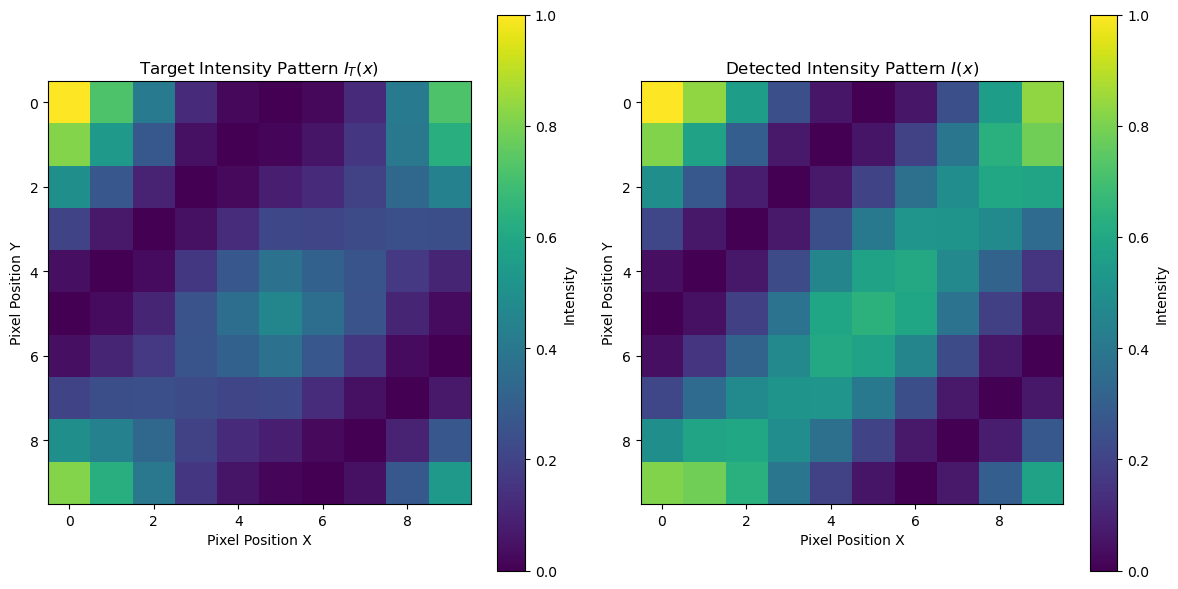

In [26]:
# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_normalized, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_normalized, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.show()

From the figure above, its shows that the zero-frequency component is domoninating the intensity pattern and is concentrated in the upper-left corner of the output image. This happens because the zero frequency is located at the (0,0) index of the Fourier-transformed array. To visualize the pattern properly, using `np.fft.fftshift` can shift the zero-frequency component of the 2D Fourier transform to the centre of the frequency domain image. This allows for observing any higher-frequency components or structures in the pattern. 

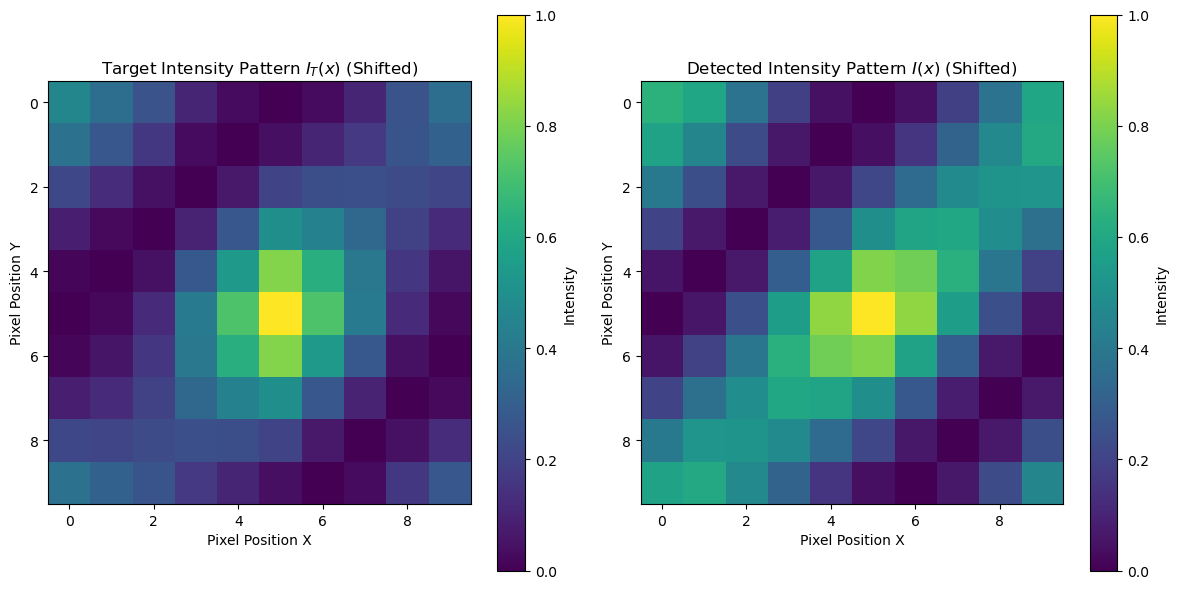

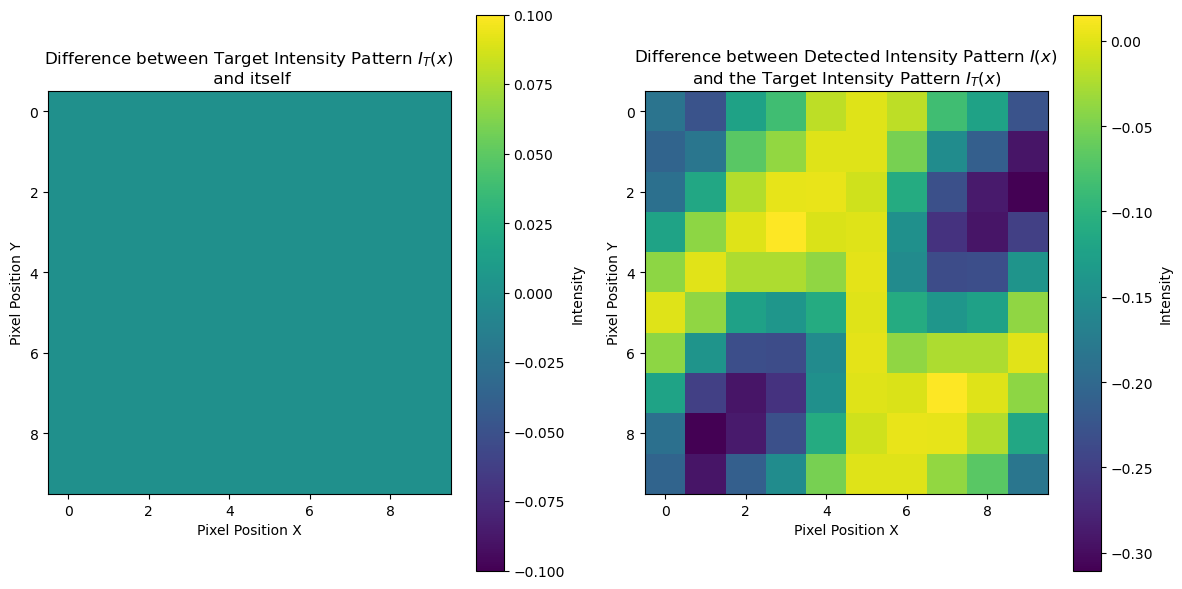

In [27]:
# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(I_x_Detected_shifted, cmap='viridis')
axes[1].set_title("Detected Intensity Pattern $I(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/Intensity.png')  # Save as PNG file

# Apply fftshift to center the zero-frequency component
I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)

intensity_difference_1 = I_x_Target_shifted - I_x_Target_shifted
intensity_difference_2 = I_x_Target_shifted - I_x_Detected_shifted

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the first intensity pattern on the left
im1 = axes[0].imshow(intensity_difference_1, cmap='viridis')
axes[0].set_title("Difference between Target Intensity Pattern $I_T(x)$ \n and itself")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[0], label="Intensity")

# Plot the second intensity pattern on the right
im2 = axes[1].imshow(intensity_difference_2, cmap='viridis')
axes[1].set_title("Difference between Detected Intensity Pattern $I(x)$ \nand the Target Intensity Pattern $I_T(x)$")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[1], label="Intensity")

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plots
plt.savefig('Image_JuypyterNotebook/Intensity_Difference.png')  # Save as PNG file
plt.show()

In [28]:
# Calculate and print the min and max values of intensity patterns
target_min = np.min(I_x_Target_shifted)
target_mean = np.mean(I_x_Target_shifted)
target_max = np.max(I_x_Target_shifted)
detected_min = np.min(I_x_Detected_shifted)
detected_mean = np.mean(I_x_Detected_shifted)
detected_max = np.max(I_x_Detected_shifted)

# Prepare markdown string
markdown_string = f"""
**Target Intensity Min Value:** {target_min:.16e}  
**Target Intensity Mean Value:** {target_mean:.4f}  
**Target Intensity Max Value:** {target_max:.4f}  

**Detected Intensity Min Value:** {detected_min:.16e}  
**Detected Intensity Mean Value:** {detected_mean:.4f}  
**Detected Intensity Max Value:** {detected_max:.4f}  

The values in the target intensity range from **{target_min:.16e}** to **{target_max:.4f}** with a mean value of **{target_mean:.4f}** which suggests a strong peak in intensity at a particular point (a focused spot or central region) and much smaller intensity values elsewhere.  

This is consistent with an optical setup that tries to focus light into a small region in the far-field. The detected pattern has minimum values of **{detected_min:.16e}** to **{detected_max:.4f}** with a mean value of **{detected_mean:.4f}**. 

The overall structure is roughly comparable to the target intensity pattern, with a peak and some distribution around it. Both the target and detected intensity patterns exhibit some symmetry, which is typical of far-field diffraction patterns where the intensity is spread symmetrically around a central peak. 

The presence of low-intensity values in specific areas, especially near-zero points, is also consistent with diffraction effects (values close to 1 due to constructive interference, and zeros due to destructive interference). 

The phase relationship between different parts of the wavefront significantly affects the final intensity distribution, and the slight mismatch between target and detected intensities could stem from incomplete optimization of the phases. Small differences in phase can result in larger discrepancies in intensity due to interference effects.
"""

In [29]:
display(Markdown(markdown_string))


**Target Intensity Min Value:** 0.0000000000000000e+00  
**Target Intensity Mean Value:** 0.2212  
**Target Intensity Max Value:** 1.0000  

**Detected Intensity Min Value:** 0.0000000000000000e+00  
**Detected Intensity Mean Value:** 0.3293  
**Detected Intensity Max Value:** 1.0000  

The values in the target intensity range from **0.0000000000000000e+00** to **1.0000** with a mean value of **0.2212** which suggests a strong peak in intensity at a particular point (a focused spot or central region) and much smaller intensity values elsewhere.  

This is consistent with an optical setup that tries to focus light into a small region in the far-field. The detected pattern has minimum values of **0.0000000000000000e+00** to **1.0000** with a mean value of **0.3293**. 

The overall structure is roughly comparable to the target intensity pattern, with a peak and some distribution around it. Both the target and detected intensity patterns exhibit some symmetry, which is typical of far-field diffraction patterns where the intensity is spread symmetrically around a central peak. 

The presence of low-intensity values in specific areas, especially near-zero points, is also consistent with diffraction effects (values close to 1 due to constructive interference, and zeros due to destructive interference). 

The phase relationship between different parts of the wavefront significantly affects the final intensity distribution, and the slight mismatch between target and detected intensities could stem from incomplete optimization of the phases. Small differences in phase can result in larger discrepancies in intensity due to interference effects.


3. Energy calculation:
   
The goal is to find the phase configuration that minimizes this energy, which corresponds to the ground state of the Ising Hamiltonian. The intensity of the interference pattern is related to
the energy of the Ising system.

\begin{equation}
\textbf{Energy} =  \int [I(x)]^2 dx
\end{equation}


The cost function is defined as the difference of the intensity, which corresponds to finding the ground state of the Ising Hamiltonian.

\begin{equation}
\textbf{Cost Function} = f = ||I(x) - I_T(x)||
\end{equation}

This function measures how far the current spin configuration is from the target intensity.


    """
    Calculates the energy (or cost) based on the difference between
    detected intensity and target intensity.
    
    Args:
        I_detected: The detected intensity pattern.
        I_target: The target intensity pattern.
    
    Returns:
        The energy (cost) value.
    """

In [30]:
# Calculate the detected intensity pattern using the Fourier-based function
I_detected_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3)))
# Calculate the target intensity pattern using the Fourier-based function
I_target_shifted = np.fft.fftshift(calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky, focal_length = 500*10**(-3)))

# compute the energy difference (cost function)
# def calculate_energy(I_detected_shifted, I_target_shifted):

#     return np.sum((I_target_shifted - I_detected_shifted)**2)

# def calculate_energy(I_x_Detected_normalized, I_x_Target_normalized):
#     """Calculate energy difference between detected and target intensity."""
#     return np.reduce_sum(tf.square(I_x_Detected_normalized - I_x_Target_normalized))

def calculate_energy(I_x_Detected_normalized, I_x_Target_normalized):
    """Calculate energy difference (cost function) between detected and target intensity."""
    return np.sum((I_x_Target_normalized - I_x_Detected_normalized)**2)

# # Calculate the energy difference
# energy_difference = calculate_energy(I_detected_shifted, I_target_shifted)

# # Print the energy difference
# print(f"Energy Difference: {energy_difference}")

## Optimization: Monte Carlo Method

The ground state energy can be found using Monte Carlo method by establishing the connection between the spin configurations and the associated energy levels. The ground state energy corresponds to the minimum energy configuration reached during simulation processes. This represents the spin configuration, or phase matrix, that produces the closet match to the target intensity pattern. 

The order of magnitude between the two patterns are large. It is advisable to implement Monto-Carlo method optimization for the evolution of the detected system to match the target intensity distribution such that the detect pattern grow closer to the target over more iterations.

The Monte Carlo method is essential to simulate the spin evolution, which is based on the concept of flippng spin or clusers of spins and measuring whether this change leads to a decrease in Hamiltonian, i.e., the differene bwtween the target intensity and the detected intensity. 

Initially, a cluster of spins (a few pixels on the SLM) would be randomly flipped and the resulting intensity pattern would be calculated. After each cluster flip, the system iteratively adjusts the phase modulations such that the resulting intensity pattern $I(x)$ would match the arbitrary target intensity pattern $I_T(x)$ (the difference between the new intensity pattern and the target intensity, i.e. $f = |I(x) - I_T(x)|$) to minimize the energy.

If the new configuration brings the system closer to the target, i.e., the difference is reduced, the new configuration would be retained. The process will be repeated for multiple iterations until the cost function is minimized, i.e. no furtehr configuration improves the energy significantly.

Since the system's evolution is purely driven by minimizing the cost function $f$, the Hamiltonian $H =  - \sum_{jh} J_{jh} \sigma_j \sigma_h$ is not explicitly calculated. The spin-spin interaction $J_{jh}$ emerge naturally from the modulation of light on the SLM and the feedback from the far-field intensity pattern.

Energy values `energy_values` is being stored into list at each iteration, and then the energy difference `energy_diffs = [energy_values[i] - energy_values[i-1] for i in range(1, len(energy)values))]` between each iterations is calculated. To check if the energy difference is decreasing, we can plot the energy values at each iteration. We can also visualize the final phase matrix to see if it matches the target phase matrix. If there is a plateau in the plot, it indicates that the energy difference converges.  Finally, after the simulation is completed, the plot is delivered to observe how the energy stabilizes over time. 

Plotting both the energy differences and energy values over iterations. The plateau behavior is checked to verify if the process has likely converged to the ground state.

### Consideration

it is important to gradually increase the cluster sizer to avoid getting stuck in local minima, this approach would be implemented by starting with single spoin flips and gradually increasing the cluster size. In the experiment, random noise and fluctuation would occur, introducing random noise in the intensity calculation is essential to simulate real-world conditions.

In [31]:
# def monte_carlo_ground_state(detected_phase_matrix, I_target_shifted, xi, W, kx, ky, iterations = 100):
#     n = detected_phase_matrix.shape[0]
    
#     # Convert the initial phase matrix to a spin matrix
#     detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
#     # Calculate the initial intensity and energy
#     I_x_Detected  = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)
#     current_energy = calculate_energy(I_x_Detected, I_target_shifted)
    
#     # Track the ground state energy and energy differences
#     ground_state_energy = current_energy
#     energy_values = [current_energy]  # Store energies
    
#     for i in range(iterations):
#         # Randomly flip a small cluster of spins (phase flip in a small region)
#         new_phase_matrix = detected_phase_matrix.copy()
#         cluster_size = np.random.randint(1, 5)  # Choose a small cluster size
#         random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
#         # Flip the phase at the selected positions
#         for index in random_indices:
#             row, col = divmod(index, n)
#             new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]
        
#         # Convert the new phase matrix to a spin matrix
#         new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
        
#         # Calculate new intensity and energy
#         new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky)
#         new_energy = calculate_energy(new_intensity, I_target_shifted)
        
#         # Track energy values
#         energy_values.append(new_energy)
        
#         # Calculate energy difference between consecutive iterations
#         energy_diff = new_energy - current_energy
        
#         # Accept the new configuration if the energy decreases
#         if new_energy < current_energy:
#             final_detected_phase_matrix = new_phase_matrix  # Accept the new phase matrix
#             current_energy = new_energy
            
#             # Update ground state energy if necessary
#             if current_energy < ground_state_energy:
#                 ground_state_energy = current_energy
        
#         # Optional: Print or track the progress
#         if i % 10 == 0:
#             print(f"Iteration {i}, Energy: {current_energy}, Ground State Energy: {ground_state_energy}, Energy Difference: {energy_diff}")
    
#     # Calculate the energy differences
#     energy_diffs = [abs(energy_values[i] - energy_values[i-1]) for i in range(1, len(energy_values))]

#     # Record the end time
#     end_time = time.time()

#     # Calculate elapsed time
#     elapsed_time = end_time - start_time

#     # Plot energy differences over iterations
#     plt.figure(figsize=(10, 6))

#     # Plot 1: Energy differences
#     plt.subplot(2, 1, 1)
#     plt.plot(energy_diffs, label="Energy Difference", color='b')
#     plt.xlabel("Iteration")
#     plt.ylabel("Energy Difference")
#     plt.title("Energy Difference Between Iterations")
#     plt.grid(True)
#     plt.legend()
    
#     # Plot 2: Energy values
#     plt.subplot(2, 1, 2)
#     plt.plot(energy_values, label="Energy Values", color='g')
#     plt.xlabel("Iteration")
#     plt.ylabel("Energy")
#     plt.title("Energy Values Over Iterations")
#     plt.grid(True)
#     plt.legend()

#     plt.tight_layout()
#     plt.show()

#     # Plot the histogram of energy values
#     plt.figure(figsize=(10, 6))
#     plt.hist(energy_values, bins=50, color='purple', alpha=0.7)
#     plt.xlabel("Energy")
#     plt.ylabel("Frequency")
#     plt.title("Histogram of Energy Values")
#     plt.grid(True)
#     plt.show()
    
#     return detected_phase_matrix, ground_state_energy

The histogram plot `plt.hist(energy_values, bins=50, color='purple', alpha=0.7)` line plots the histogram of the `energy_values`, is to give a visual idea of the distribution of energies throughout the simulation, helping to understand how frequently different energy levels occur during the process. The `bins` parameters can be adjusted for finner or coarser binning, depending on how spread the energies are. To ensure the histogram plot reflects the full distribution of energy values generated during the Monte Carlo process, it is placed after all iterations are done. 

In [32]:
# # # Record the start time
# start_time = time.time()

# with tf.device('/GPU:0'):
#     monte_carlo_ground_state(detected_phase_matrix, I_target_shifted, xi, W, kx, ky, iterations = 100)

# # # Record the end time
# end_time = time.time()

# # # Calculate elapsed time
# elapsed_time = end_time - start_time

In [33]:
# # Print the elapsed time
# print(f"Computation Time: {elapsed_time:.4f} seconds")

The detected phase matrix in the final state is visualized to check if the spatial structure of the configuration could minimize the energy. 

In [34]:
# # Create the pixel-like image
# # Create the plot
# fig, axes = plt.subplots(1, 2, figsize=(10, 5)) # gridspec_kw={'width_ratios': [1, 1.1]}

# # Plot the spin matrix on the left
# axes[0].imshow(target_phase_matrix, cmap='viridis')
# axes[0].set_title("Pixel Representation of \n Target Phase Matrix")
# axes[0].set_xlabel("Pixel Position x")
# axes[0].set_ylabel("Pixel Position y")

# # Plot the random phase matrix on the right
# cax = axes[1].imshow(detected_phase_matrix, cmap='viridis')
# axes[1].set_title("Pixel Representation of \n Final Detected Phase Matrix after iteration")
# axes[1].set_xlabel("Pixel Position x")
# axes[1].set_ylabel("Pixel Position y")

# # Add colorbar for the phase matrix plot
# cbar3 = fig.colorbar(cax, ax=axes[0])
# cbar4 = fig.colorbar(cax, ax=axes[1])

# # Set the colorbar ticks and labels
# cbar_ticks = [0, np.pi]
# cbar_labels = ['0', '$\pi$']

# cbar3.set_ticks(cbar_ticks)
# cbar3.set_ticklabels(cbar_labels)

# cbar4.set_ticks(cbar_ticks)
# cbar4.set_ticklabels(cbar_labels)

# # Show the plots
# plt.tight_layout()
# plt.show()

In [35]:
# print(detected_phase_matrix, target_phase_matrix)

To visualize how often specific energy values values are distributed and how signifcant changes in energy changes appear over iteration, a histogram is plotted.

## Simulate Annealing (SA)

Simulated Annealing is an extension to the traditional Monte Carlo Algorithm, where the system's exploration of phase space is improved by accpeting the increased energy with some probability. The probability decrease over time, simulating a cooling process that helps the system settle into a global minumum rather than getting stuck in local minima. SA is direcetly integrated into the Monte Carlo method, which is to modify how decision about accepting or rejecting a move are made within the Monto carlo loop. There is no need to separate it out into a different function since the primary change lies in adjusting how moves are accepted as a function of temperature. 

Temperature `temperature` is introduced as a parameter, starting with a higher value and then gradually decrease it over iterations by multiplying it with another paramter `cooling_rate` after each iteraion. The energy-lowering moves are only accpeted in traditional Monte Carlo, while the both enery-lowering and energy-increasing moves with certain probability are also accepted with the integration of SA. The upated criterion is that the new configuration is accepted if the new energy is lower. If the new energy is higher, it will be accpeted with a probability given be $P = e^{-\frac{\Delta E}{T}}$, where $\Delta E$ is the energy difference and $T$ is the temperature. To ensure the system can explore more configuration and escape local minima, the temperature decrease over time. However, evenutally, the system behaves more like traditional Monte Carlo method, only accpeting downhill moves. This reduces the probability of accepting higher-energy configurations as the algorithm progresses. 

By selecting clusters of spins with gradually increasing sizes, the probability of trapping into local minima can be reduced. A clear control over how the cluster size changes over time should be emphasized. 

1.	The cluster size starts small and gradually increases with each iteration 
2.	As the algorithm progresses, larger clusters are flipped to explore a broader space of configurations, helping to escape local minima.

Instead of printing the current energy 5 iterations, tracking energy deltas (differences between conseuctive energies) to better monitor whether the system is convergining or oscillating between values. 

instead of linearly reducing the temperature by a constant cooling rate, it could be adapted based on energy deltas. Reducing the temperature faster when energy changes are small, reducing it slower when the system is still far from converging. 


In [36]:
# def monte_carlo_with_simulated_annealing(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=100, initial_temperature=1.5, cooling_rate=0.99):
#     n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    
#     # Convert the initial phase matrix to a spin matrix
#     detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
#     # Calculate and normalize the initial intensity distribution only once
#     I_x_Target = calculate_intensity_fourier(xi, target_spin_matrix, W, kx, ky)
#     I_x_Target_normalized = (I_x_Target - np.min(I_x_Target)) / (np.max(I_x_Target) - np.min(I_x_Target))
#     I_x_Target_shifted = np.fft.fftshift(I_x_Target_normalized)
    
#     # Calculate the detected intensity and normalize it
#     I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)
#     I_x_Detected_shifted = np.fft.fftshift(I_x_Detected)
#     I_x_Detected_normalized = (I_x_Detected_shifted - np.min(I_x_Detected_shifted)) / (np.max(I_x_Detected_shifted) - np.min(I_x_Detected_shifted))

#     # Initial energy based on normalized intensity
#     current_energy = calculate_energy(I_x_Detected_normalized, I_x_Target_shifted)  

#     # Initialize ground state energy and energy tracking
#     ground_state_energy = current_energy
#     energy_values = [current_energy]
#     temperature = initial_temperature

#     for i in range(iterations):
#         # Randomly flip a small cluster of spins
#         new_phase_matrix = detected_phase_matrix.copy()
#         cluster_size = np.random.randint(1, 5)
#         random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
#         for index in random_indices:
#             row, col = divmod(index, n)
#             new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
#         # Convert the new phase matrix to a spin matrix
#         new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
#         new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky)
#         new_intensity_shifted = np.fft.fftshift(new_intensity)
        
#         # Normalize the new intensity
#         new_intensity_normalized = (new_intensity_shifted - np.min(new_intensity_shifted)) / (np.max(new_intensity_shifted) - np.min(new_intensity_shifted))

#         # Calculate the new energy
#         new_energy = calculate_energy(new_intensity_normalized, I_x_Target_shifted)
#         energy_diff = new_energy - current_energy
#         energy_values.append(new_energy)

#         # Simulated annealing acceptance condition
#         if new_energy < current_energy:
#             detected_phase_matrix = new_phase_matrix
#             current_energy = new_energy
#         else:
#             acceptance_prob = np.exp(-energy_diff / temperature)
#             if np.random.rand() < acceptance_prob:
#                 detected_phase_matrix = new_phase_matrix
#                 current_energy = new_energy

#         if current_energy < ground_state_energy:
#             ground_state_energy = current_energy

#         # Cooling
#         temperature *= cooling_rate
        
#         # Print progress every 5 iterations
#         if i % 5 == 0:
#             print(f"Iteration {i}, Energy: {current_energy}, Ground State Energy: {ground_state_energy}, Temperature: {temperature}")
    
#     return detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized


In [37]:
# def monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=100, initial_temperature=1.5, cooling_rate=0.99):
#     n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    
#     detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
#     # Normalize the target intensity
#     I_x_Target_normalized = (I_x_Target_shifted - np.min(I_x_Target_shifted)) / (np.max(I_x_Target_shifted) - np.min(I_x_Target_shifted))
    
#     # Compute initial detected intensity and normalize it
#     I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky)
#     I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

#     current_energy = calculate_energy(I_x_Detected_normalized, I_x_Target_normalized)
#     ground_state_energy = current_energy

#     # Track energy values for visualization
#     energy_values = [current_energy]
    
#     temperature = initial_temperature

#     for i in range(iterations):
#         # Gradually increase cluster size
#         cluster_size = min(max(1, int(i / (iterations / 10))), n * n // 2)  # Increase size over iterations and cap it

#         # Randomly flip a gradually increasing cluster of spins
#         new_phase_matrix = detected_phase_matrix.copy()
#         random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
#         for index in random_indices:
#             row, col = divmod(index, n)
#             new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
#         # Convert the new phase matrix to a spin matrix and calculate new intensity
#         new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
#         new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky)
#         new_intensity_normalized = (new_intensity - np.min(new_intensity)) / (np.max(new_intensity) - np.min(new_intensity))
        
#         # Calculate new energy
#         new_energy = calculate_energy(new_intensity_normalized, I_x_Target_normalized)
#         energy_diff = new_energy - current_energy

#         # Accept the new configuration if it reduces energy, or with some probability if it increases energy (for simulated annealing)
#         if new_energy < current_energy or np.random.rand() < np.exp(-energy_diff / temperature):
#             detected_phase_matrix = new_phase_matrix
#             current_energy = new_energy
        
#         # Track the ground state energy
#         if current_energy < ground_state_energy:
#             ground_state_energy = current_energy

#         # Append the current energy to the list for tracking
#         energy_values.append(current_energy)
        
#         # Cooling step
#         temperature *= cooling_rate

#         # Optionally print progress every few iterations
#         if i % 5 == 0:
#             print(f"Iteration {i}, Energy: {current_energy:.6f}, Ground State Energy: {ground_state_energy:.6f}, Temperature: {temperature:.6f}")

#     # Return all 4 values: detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized
#     return detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized


In [38]:
def calculate_ising_energy(spin_matrix, J):
    # Assuming J is a uniform matrix and calculating the energy for each neighboring pair
    energy = 0
    for i in range(spin_matrix.shape[0]):
        for j in range(spin_matrix.shape[1]):
            # Assuming periodic boundary conditions for nearest neighbor interaction
            energy -= J[i, j] * spin_matrix[i, j] * (spin_matrix[(i+1) % spin_matrix.shape[0], j] + 
                                                     spin_matrix[i, (j+1) % spin_matrix.shape[1]])
    return energy

In [39]:
def calculate_magnetization(spin_matrix):
    """Calculate the magnetization m of the system."""
    return np.mean(spin_matrix)

In [40]:
# def monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=150, initial_temperature=1.5, cooling_rate=0.99):
#     n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    
#     detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
#     # Normalize the target intensity
#     I_x_Target_normalized = (I_x_Target_shifted - np.min(I_x_Target_shifted)) / (np.max(I_x_Target_shifted) - np.min(I_x_Target_shifted))
    
#     # Compute initial detected intensity and normalize it
#     I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
#     I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

#     current_energy = np.sum((I_x_Detected_normalized - I_x_Target_normalized)**2)  # Calculate energy as squared error
#     ground_state_energy = current_energy

#     # Track energy values for visualization
#     energy_values = [current_energy]
#     temperature = initial_temperature

#     for i in range(iterations):
#         # Gradually increase cluster size (logarithmic scaling)
#         cluster_size = max(1, int(np.log(i+1) / np.log(iterations+1) * (n * n // 2)))  # Logarithmic growth in cluster size
        
#         # Randomly flip a gradually increasing cluster of spins
#         new_phase_matrix = detected_phase_matrix.copy()
#         random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
#         for index in random_indices:
#             row, col = divmod(index, n)
#             new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
#         # Convert the new phase matrix to a spin matrix and calculate new intensity
#         new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
#         new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
#         new_intensity_normalized = (new_intensity - np.min(new_intensity)) / (np.max(new_intensity) - np.min(new_intensity))
        
#         # Calculate new energy
#         new_energy = np.sum((new_intensity_normalized - I_x_Target_normalized)**2)  # Calculate energy as squared error
#         energy_diff = new_energy - current_energy

#         # Accept the new configuration if it reduces energy, or with some probability if it increases energy (for simulated annealing)
#         if new_energy < current_energy or np.random.rand() < np.exp(-energy_diff / temperature):
#             detected_phase_matrix = new_phase_matrix
#             current_energy = new_energy
        
#         # Track the ground state energy
#         if current_energy < ground_state_energy:
#             ground_state_energy = current_energy

#         # Append the current energy to the list for tracking
#         energy_values.append(current_energy)
        
#         # Adaptive cooling: slow down cooling if energy_diff is large
#         cooling_factor = cooling_rate if energy_diff < 0.01 else cooling_rate * 0.95
#         temperature *= cooling_factor

#         # Optionally print progress every few iterations
#         if i % 5 == 0:
#             print(f"Iteration {i}, Energy: {current_energy:.6f}, Ground State Energy: {ground_state_energy:.6f}, Cluster Size: {cluster_size}, Temperature: {temperature:.6f}")

#     # Return all 4 values: detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized
#     return detected_phase_matrix, ground_state_energy, energy_values, new_intensity_normalized


def monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=150, initial_temperature=1.5, cooling_rate=0.99):
    n = detected_phase_matrix.shape[0]  # Size of the phase matrix
    detected_spin_matrix = binary_phase_to_spin(detected_phase_matrix)
    
    # Initialize J matrix (interaction strength) for Ising model (assumed to be uniform)
    J = np.ones((n, n))  # Assuming uniform interaction between all spins

    # Normalize the target intensity
    I_x_Target_normalized = (I_x_Target_shifted - np.min(I_x_Target_shifted)) / (np.max(I_x_Target_shifted) - np.min(I_x_Target_shifted))
    
    # Compute initial detected intensity and normalize it
    I_x_Detected = calculate_intensity_fourier(xi, detected_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
    I_x_Detected_normalized = (I_x_Detected - np.min(I_x_Detected)) / (np.max(I_x_Detected) - np.min(I_x_Detected))

    # Intensity-based cost function energy
    current_energy = np.sum((I_x_Detected_normalized - I_x_Target_normalized)**2)
    ground_state_energy = current_energy

    # Physical energy H and magnetization m tracking
    ising_energy = calculate_ising_energy(detected_spin_matrix, J)
    magnetization = calculate_magnetization(detected_spin_matrix)
    
    # Track energy values for visualization
    energy_values = [current_energy]
    ising_energy_values = [ising_energy]
    magnetization_values = [magnetization]
    
    temperature = initial_temperature

    for i in range(iterations):
        # Gradually increase cluster size (logarithmic scaling)
        cluster_size = max(1, int(np.log(i+1) / np.log(iterations+1) * (n * n // 2)))
        
        # Randomly flip a gradually increasing cluster of spins
        new_phase_matrix = detected_phase_matrix.copy()
        random_indices = np.random.choice(n * n, cluster_size, replace=False)
        
        for index in random_indices:
            row, col = divmod(index, n)
            new_phase_matrix[row, col] = np.pi - new_phase_matrix[row, col]  # Flip the phase
        
        # Convert the new phase matrix to a spin matrix and calculate new intensity
        new_spin_matrix = binary_phase_to_spin(new_phase_matrix)
        new_intensity = calculate_intensity_fourier(xi, new_spin_matrix, W, kx, ky, focal_length = 500*10**(-3))
        new_intensity_normalized = (new_intensity - np.min(new_intensity)) / (np.max(new_intensity) - np.min(new_intensity))
        
        # Calculate new intensity-based energy (cost function)
        new_energy = np.sum((new_intensity_normalized - I_x_Target_normalized)**2)
        energy_diff = new_energy - current_energy

        # Simulated annealing acceptance condition
        if new_energy < current_energy or np.random.rand() < np.exp(-energy_diff / temperature):
            detected_phase_matrix = new_phase_matrix
            current_energy = new_energy
            detected_spin_matrix = new_spin_matrix
        
        # Track physical energy H and magnetization m at every iteration
        ising_energy = calculate_ising_energy(detected_spin_matrix, J)
        magnetization = calculate_magnetization(detected_spin_matrix)

        # Track the ground state energy
        if current_energy < ground_state_energy:
            ground_state_energy = current_energy

        # Append the current values to the tracking lists
        energy_values.append(current_energy)
        ising_energy_values.append(ising_energy)
        magnetization_values.append(magnetization)
        
        # Adaptive cooling: slow down cooling if energy_diff is large
        cooling_factor = cooling_rate if energy_diff < 0.01 else cooling_rate * 0.95
        temperature *= cooling_factor

        # Optionally print progress every few iterations
        if i % 5 == 0:
            print(f"Iteration {i}, Energy: {current_energy:.6f}, Ground State Energy: {ground_state_energy:.6f}, Cluster Size: {cluster_size}, Temperature: {temperature:.6f}, Ising Energy: {ising_energy:.6f}, Magnetization: {magnetization:.6f}")

    # Return all values: phase matrix, ground state energy, energy values, ising energy values, magnetization values, and normalized intensity
    return detected_phase_matrix, ground_state_energy, energy_values, ising_energy_values, magnetization_values, new_intensity_normalized


In [41]:
def visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations):
    # Apply FFT shift to the final intensity for visualization
    I_x_Final_Detected_shifted = np.fft.fftshift(new_intensity_normalized)
    
    # Create a figure with two subplots side by side for the intensity patterns
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
    # Plot the target intensity pattern on the left
    im1 = axes[0].imshow(I_x_Target_shifted, cmap='viridis')
    axes[0].set_title("Target Intensity Pattern $I_T(x)$ (Shifted)")
    axes[0].set_xlabel("Pixel Position X")
    axes[0].set_ylabel("Pixel Position Y")
    fig.colorbar(im1, ax=axes[0], label="Intensity")
    
    # Plot the detected intensity pattern on the right (after iterations)
    im2 = axes[1].imshow(I_x_Final_Detected_shifted, cmap='viridis')
    axes[1].set_title(f"Detected Intensity $I_D(x)$ (Shifted) at Iteration {iterations}")
    axes[1].set_xlabel("Pixel Position X")
    axes[1].set_ylabel("Pixel Position Y")
    fig.colorbar(im2, ax=axes[1], label="Intensity")
    
    # Adjust layout and display the plots
    plt.tight_layout()
    plt.savefig('Image_JuypyterNotebook/Intensity_AfterIteraion.png')  # Save as PNG file
    plt.show()

    # Calculate the energy differences between iterations
    energy_diffs = [energy_values[i] - energy_values[i-1] for i in range(1, len(energy_values))]
    
    # Plot energy differences and values over iterations
    plt.figure(figsize=(10, 6))
    
    # Plot 1: Energy differences
    plt.subplot(2, 1, 1)
    plt.plot(range(1, len(energy_diffs) + 1), energy_diffs, label="Energy Difference", color='b')
    plt.xlabel("Iteration")
    plt.ylabel("Energy Difference")
    plt.title("Energy Difference Between Iterations")
    plt.grid(True)
    plt.legend()
    
    # Plot 2: Energy values
    plt.subplot(2, 1, 2)
    plt.plot(range(len(energy_values)), energy_values, label="Energy Values", color='g')
    plt.axhline(y=ground_state_energy, color='r', linestyle='--', label="Ground State Energy")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Energy Values Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.savefig('Image_JuypyterNotebook/EnergyDifference_EnergyValues.png')  # Save as PNG file
    plt.show()

    # Plot the histogram of energy values
    plt.figure(figsize=(10, 6))
    plt.hist(energy_values, bins=50, color='purple', alpha=0.7)
    plt.xlabel("Energy")
    plt.ylabel("Frequency")
    plt.title("Histogram of Energy Values")
    plt.grid(True)
    plt.savefig('Image_JuypyterNotebook/HistogramEnergy.png')  # Save as PNG file
    plt.show()

    # Visualize Ising Energy H over iterations
    plt.plot(ising_energy_values, label="Ising Energy H")
    plt.xlabel("Iteration")
    plt.ylabel("Energy")
    plt.title("Physical Energy H Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.savefig('Image_JuypyterNotebook/PhysicalEnergy.png')  # Save as PNG file
    plt.show()
    
    # Visualize Magnetization over iterations
    plt.plot(magnetization_values, label="Magnetization m")
    plt.xlabel("Iteration")
    plt.ylabel("Magnetization")
    plt.title("Magnetization Over Iterations")
    plt.grid(True)
    plt.legend()
    plt.savefig('Image_JuypyterNotebook/Magnetization.png')  # Save as PNG file
    plt.show()

Iteration 0, Energy: 4.359009, Ground State Energy: 4.115482, Cluster Size: 1, Temperature: 1.410750, Ising Energy: 12.000000, Magnetization: -0.040000
Iteration 5, Energy: 5.421702, Ground State Energy: 4.115482, Cluster Size: 17, Temperature: 1.092749, Ising Energy: -12.000000, Magnetization: -0.060000
Iteration 10, Energy: 4.943159, Ground State Energy: 4.115482, Cluster Size: 23, Temperature: 0.846430, Ising Energy: 4.000000, Magnetization: -0.160000
Iteration 15, Energy: 3.113060, Ground State Energy: 3.113060, Cluster Size: 27, Temperature: 0.655634, Ising Energy: -12.000000, Magnetization: -0.120000
Iteration 20, Energy: 3.113060, Ground State Energy: 3.113060, Cluster Size: 30, Temperature: 0.482453, Ising Energy: -12.000000, Magnetization: -0.120000
Iteration 25, Energy: 3.113060, Ground State Energy: 3.113060, Cluster Size: 32, Temperature: 0.355017, Ising Energy: -12.000000, Magnetization: -0.120000
Iteration 30, Energy: 3.113060, Ground State Energy: 3.113060, Cluster Size:

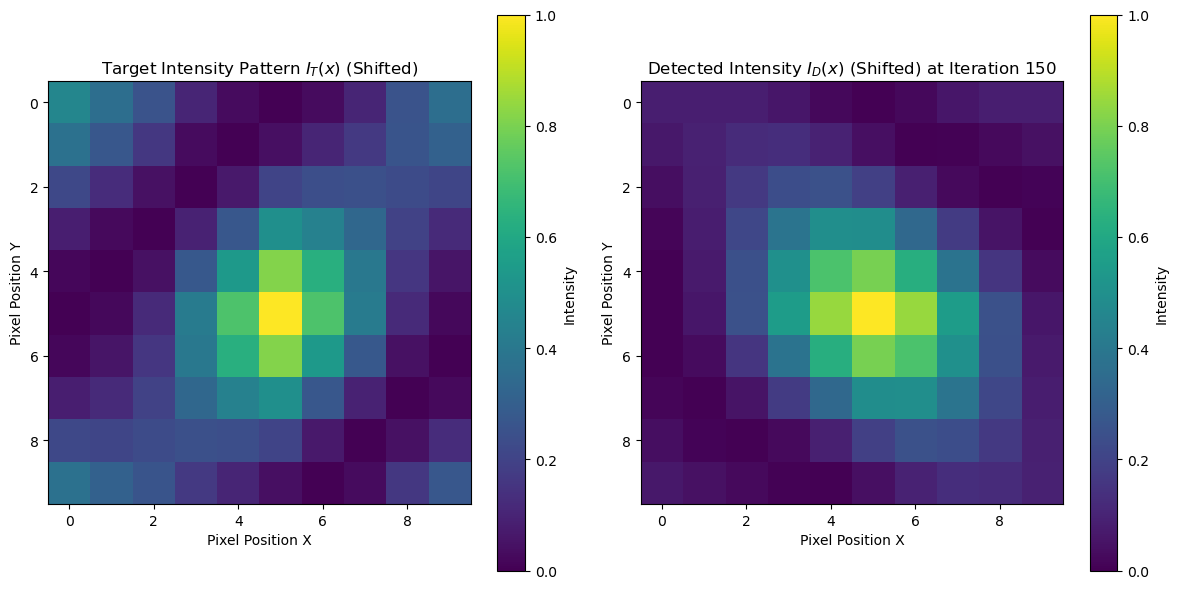

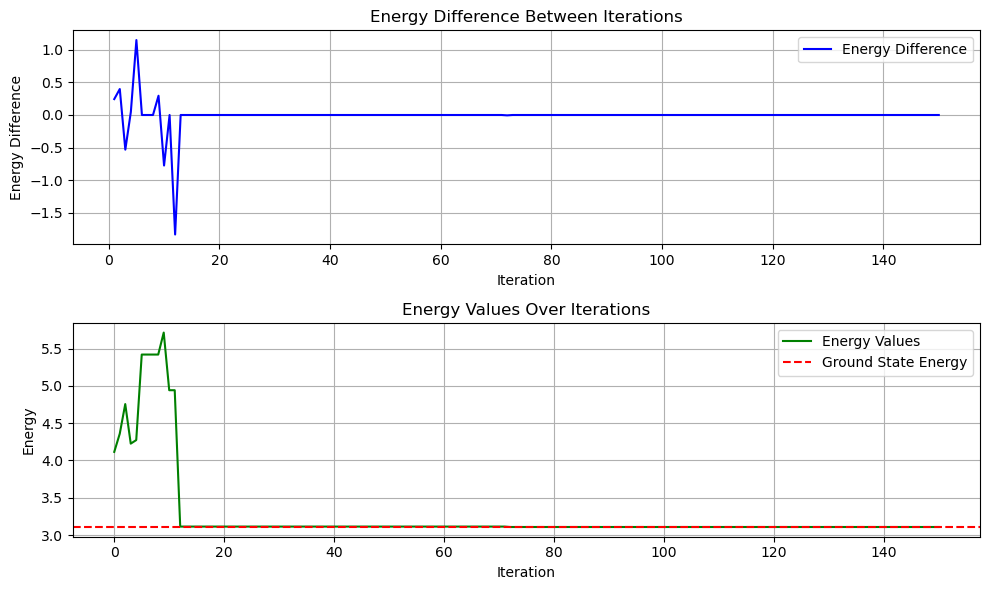

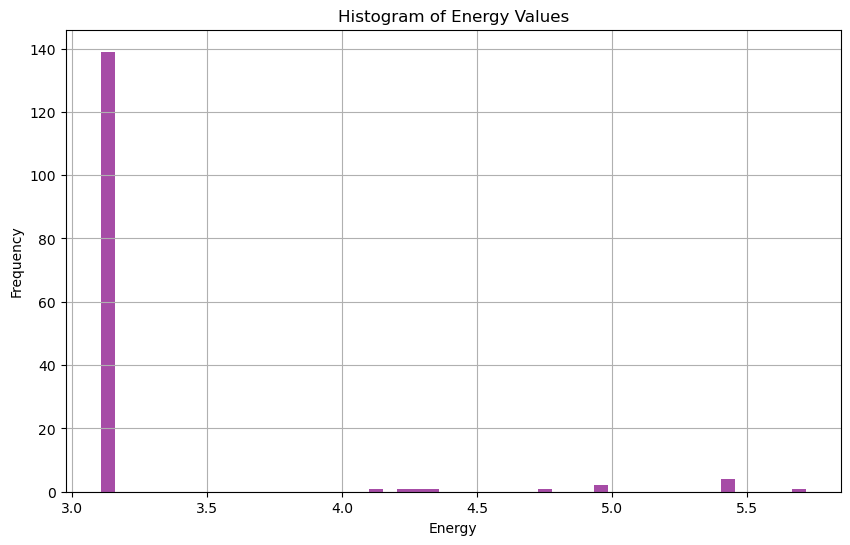

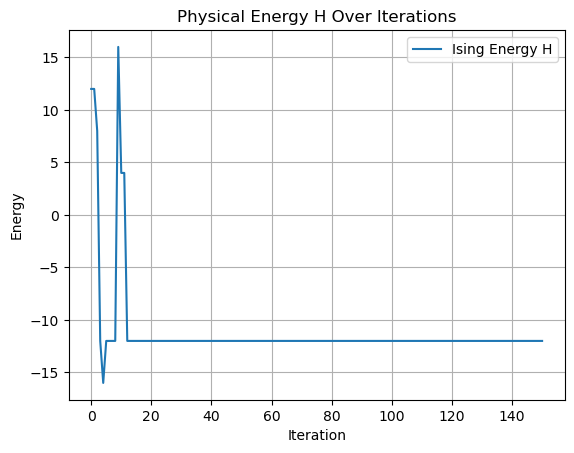

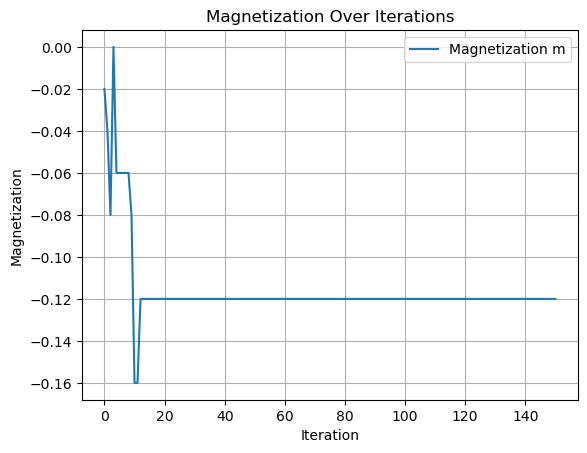

Elapsed Time: 40.09 seconds


In [42]:
# Record the start time
start_time_SA = time.time()

# Replace with your GPU setup if applicable
# with tf.device('/GPU:0'):
detected_phase_matrix, ground_state_energy, energy_values, ising_energy_values, magnetization_values, new_intensity_normalized = monte_carlo_with_feedback(detected_phase_matrix, I_x_Target_shifted, xi, W, kx, ky, iterations=150, initial_temperature=1.5, cooling_rate=0.99)

visualize_results(I_x_Target_shifted, new_intensity_normalized, energy_values, ground_state_energy, iterations=150)

# Record the end time
end_time_SA = time.time()

# Calculate elapsed time
elapsed_time_SA = end_time_SA - start_time_SA
print(f"Elapsed Time: {elapsed_time_SA:.2f} seconds")

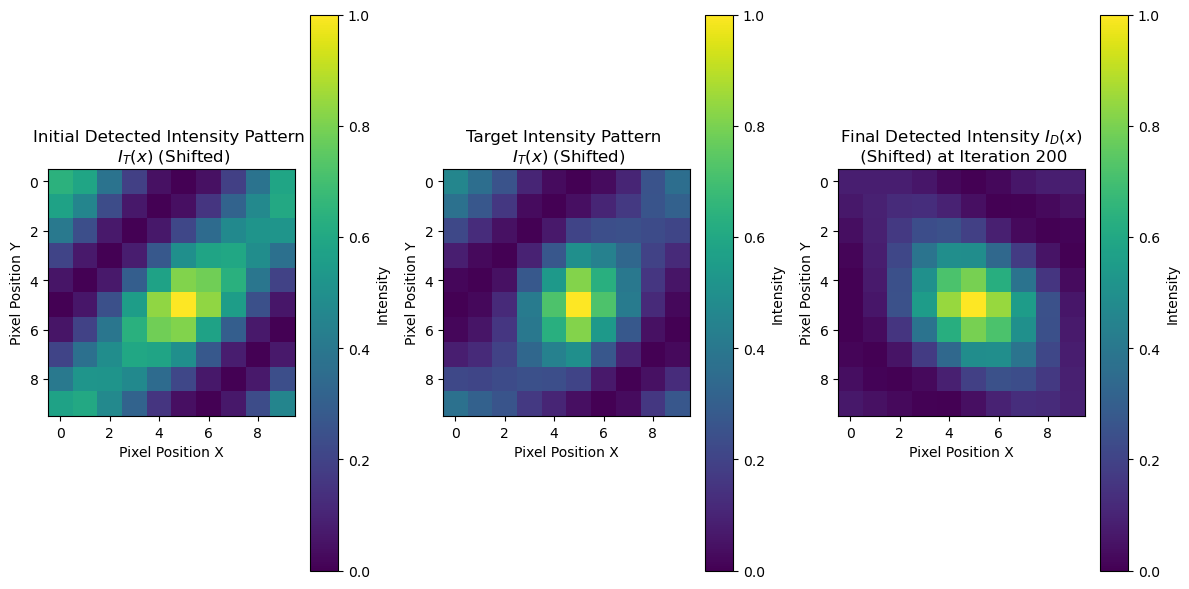

In [43]:
# Assuming you have already calculated 'new_intensity' in the Monte Carlo simulated annealing
I_x_Final_Detected_shifted =  np.fft.fftshift(new_intensity_normalized)  # Final detected intensity after the iterations
# I_x_Detected_shifted = np.fft.fftshift(I_x_Detected_normalized)  # Detected intensity before iterations (initial state)

# Create a figure with two subplots side by side for the intensity patterns
fig, axes = plt.subplots(1, 3, figsize=(12, 6))

# Plot the initial detected intensity pattern on the left
im0 = axes[0].imshow(I_x_Detected_shifted, cmap='viridis')
axes[0].set_title("Initial Detected Intensity Pattern \n $I_T(x)$ (Shifted)")
axes[0].set_xlabel("Pixel Position X")
axes[0].set_ylabel("Pixel Position Y")
fig.colorbar(im0, ax=axes[0], label="Intensity")

# Plot the target intensity pattern on the left
im1 = axes[1].imshow(I_x_Target_shifted, cmap='viridis')
axes[1].set_title("Target Intensity Pattern \n $I_T(x)$ (Shifted)")
axes[1].set_xlabel("Pixel Position X")
axes[1].set_ylabel("Pixel Position Y")
fig.colorbar(im1, ax=axes[1], label="Intensity")

# Plot the final detected intensity pattern on the right (after iterations)
im2 = axes[2].imshow(I_x_Final_Detected_shifted, cmap='viridis')
axes[2].set_title(f"Final Detected Intensity $I_D(x)$ \n (Shifted) at Iteration {200}")
axes[2].set_xlabel("Pixel Position X")
axes[2].set_ylabel("Pixel Position Y")
fig.colorbar(im2, ax=axes[2], label="Intensity")

# Adjust layout and display the plots
plt.tight_layout()
plt.savefig('Image_JuypyterNotebook/IntensityComparisonAfterIteration.png')  # Save as PNG file
plt.show()

Target Intensity (I_x_Target_shifted): 

This pattern shows a clear, structured distribution of intensity, which seems to be well-defined.
Detected Intensity (I_x_Detected_shifted): 

The detected intensity appears to be more spread out and less structured compared to the target intensity. This might indicate that the detection did not match the target intensity pattern well.

Final Detected Intensity (I_x_Final_Detected_shifted): 

This seems to have improved compared to I_x_Detected_shifted, showing more defined features, but it still looks quite different from I_x_Target_shifted.

From the generated plot, we observe that there are still some mismatch between target and the final intensity patterns. Despite the iterations, the final detected intensity still resembles the initial detected inensity in certain ways. Also, there is a substantial difference between the magnitude of the final detected intensity and that of the target intensity. 

The close proximity between the initial and final detected pattern suggests that the optimization algorithm may not be exploring the search space effectively. One of the reason could be the temperature schedule or the cooling rate in SA process may be too conservative, leading to insufficient exploration or early convergence to a local minimum. If the function does not properly account for the magnitude scaling, the optimization may not be sensitive enough  to bridge this gap. 


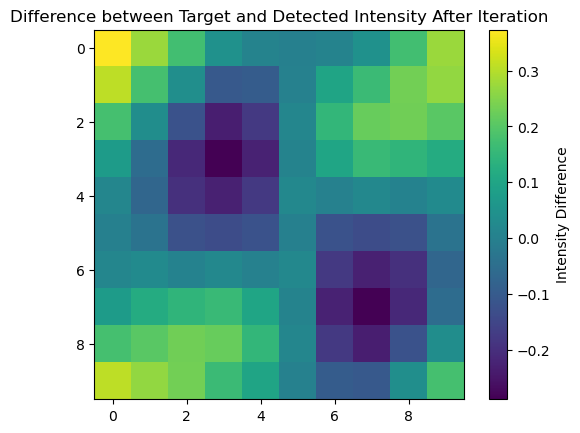

In [44]:
intensity_difference = I_x_Target_shifted - I_x_Final_Detected_shifted
plt.imshow(intensity_difference, cmap='viridis')
plt.colorbar(label="Intensity Difference")
plt.title("Difference between Target and Detected Intensity After Iteration")
plt.savefig('Image_JuypyterNotebook/IntensityDifferenceAfterIteration.png')  # Save as PNG file
plt.show()

In [45]:
I_x_Final_Detected_shifted, I_x_Detected_shifted, I_x_Target_shifted

(array([[8.48826030e-02, 8.58856987e-02, 8.29934083e-02, 5.88137446e-02,
         2.04878319e-02, 0.00000000e+00, 2.04878319e-02, 5.88137446e-02,
         8.29934083e-02, 8.58856987e-02],
        [6.51657886e-02, 9.31865686e-02, 1.23812245e-01, 1.31526739e-01,
         9.66007621e-02, 3.98674800e-02, 3.01230974e-03, 4.73735114e-03,
         2.49516397e-02, 4.41666269e-02],
        [3.64136756e-02, 8.95147126e-02, 1.65912971e-01, 2.37676662e-01,
         2.47486726e-01, 1.88281193e-01, 8.90366264e-02, 2.38307286e-02,
         3.43792367e-04, 7.98605323e-03],
        [1.18703509e-02, 8.00937208e-02, 2.12236376e-01, 3.84362636e-01,
         4.95452530e-01, 4.89033352e-01, 3.37216114e-01, 1.73751427e-01,
         5.25916491e-02, 3.26010246e-03],
        [2.03459796e-03, 7.10195102e-02, 2.42942682e-01, 5.01250775e-01,
         7.17842079e-01, 7.93689696e-01, 6.26151588e-01, 3.81180580e-01,
         1.53851454e-01, 2.92811688e-02],
        [6.77967319e-20, 6.01028048e-02, 2.46415880e-01, 5.5

In [46]:
# Compute the Mean Squared Error for both intensity differences
mse_diff_1 = np.mean((I_x_Target_shifted - I_x_Detected_shifted) ** 2)
mse_diff_2 = np.mean((I_x_Target_shifted - I_x_Final_Detected_shifted) ** 2)

# Compare the MSE values
if mse_diff_1 < mse_diff_2:
    print("I_x_Detected_shifted is closer to the target intensity pattern.")
else:
    print("I_x_Final_Detected_shifted is closer to the target intensity pattern.")
    
print(f"MSE for I_x_Detected_shifted: {mse_diff_1}")
print(f"MSE for I_x_Final_Detected_shifted: {mse_diff_2}")

I_x_Detected_shifted is closer to the target intensity pattern.
MSE for I_x_Detected_shifted: 0.021634827739456387
MSE for I_x_Final_Detected_shifted: 0.024486149127360895


In [47]:
# Compute the L2 norm (Euclidean distance) for both intensity differences
l2_diff_1 = np.linalg.norm(I_x_Target_shifted - I_x_Detected_shifted)
l2_diff_2 = np.linalg.norm(I_x_Target_shifted - I_x_Final_Detected_shifted)

# Compare the L2 values
if l2_diff_1 < l2_diff_2:
    print("I_x_Detected_shifted is closer to the target intensity pattern based on L2 norm.")
else:
    print("I_x_Final_Detected_shifted is closer to the target intensity pattern based on L2 norm.")
    
print(f"L2 norm for I_x_Detected_shifted: {l2_diff_1}")
print(f"L2 norm for I_x_Final_Detected_shifted: {l2_diff_2}")

I_x_Detected_shifted is closer to the target intensity pattern based on L2 norm.
L2 norm for I_x_Detected_shifted: 1.470878232195187
L2 norm for I_x_Final_Detected_shifted: 1.5648050718016255


It is possible that the standard Monte Carlo method might find a lower energy minimum. The methods are stochastic such that the results can vary between runs due to the rnadomness in selecting whihc spins to flip. If the initial phase matrices for both methods are different, they may explore different paths through the energy landscape. Besides, if the temperature decreases too quickly or the cooling rate is too large in the SA method, the system might not explore enough of the energy landscape to find the global minimum, of which have to be carefully tuned. Added to it, SA might need more iterations to outperform the standarrd Monte Carlo method.


The flipping small clusters of phases (random clusters of size 1 to 5) may help explore local neighbourhoods, but it may not be sufficient to explore larger regions of the solution space. Besides, the cooling rate might be too fast or to slow depending on the nature of the problem. If the temperature drops too quickly, the algorihem can get stuck in local minima. It is advisable to introduce both adaptive cluster size and cooling rate that starts small and increase grdaully as the algorithm progress based on the energy landscape. 


In [48]:
# import tensorflow as tf
# import numpy as np

# # Specify the directory to save the profiling data
# logdir = 'profiler_logs'

# # Define a function to compute energy (placeholder example)
# def compute_energy(state):
#     # Replace with your actual energy calculation (e.g., Ising model, etc.)
#     return tf.reduce_sum(state ** 2)

# # Initialize random state (could represent a physical system's configuration)
# def random_state(n):
#     return tf.random.uniform((n, n))

# # Simulated Annealing process
# def simulated_annealing(n, iterations):
#     state = random_state(n)
#     energy = compute_energy(state)

#     for i in range(iterations):
#         # Propose a new state (this is a placeholder; replace with actual transition logic)
#         new_state = state + tf.random.normal(state.shape) * 0.1
#         new_energy = compute_energy(new_state)

#         # Accept or reject the new state based on energy difference
#         if new_energy < energy:
#             state = new_state
#             energy = new_energy
    
#     return energy

# # Start profiling
# tf.profiler.experimental.start(logdir)

# # Run the SA process
# with tf.device('/GPU:0'):
#     final_energy = simulated_annealing(n=10, iterations=1000)

# # Stop profiling
# tf.profiler.experimental.stop()

# # Print final energy
# print("Final Energy:", final_energy)

# # # Load TensorBoard to visualize the profiling results
# # %load_ext tensorboard
# # %tensorboard --logdir=profiler_logs

# Draft

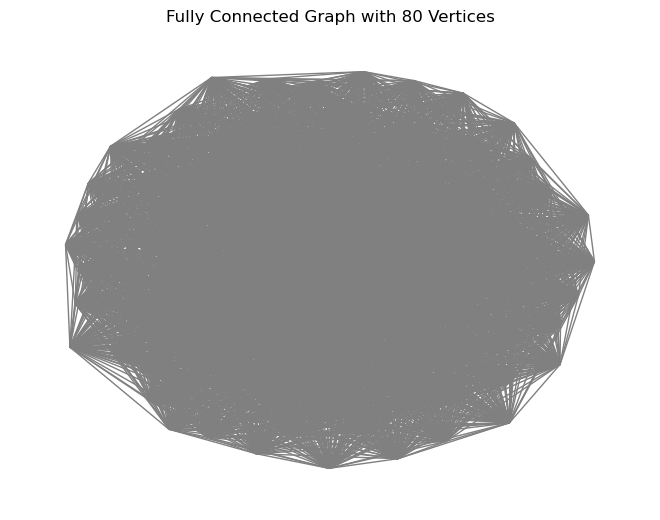

In [49]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import numpy as np

# def generate_fully_connected_mobius_ladder(n):
#     """Generate an unweighted Möbius ladder graph with fully connected vertices."""
#     G = nx.Graph()
    
#     # Add nodes
#     G.add_nodes_from(range(2 * n))
    
#     # Add horizontal edges (Möbius ladder structure)
#     horizontal_edges = [(i, (i + 1) % n) for i in range(n)] + \
#                        [(i + n, ((i + 1) % n) + n) for i in range(n)]
#     G.add_edges_from(horizontal_edges)
    
#     # Add vertical edges
#     vertical_edges = [(i, i + n) for i in range(n)]
#     G.add_edges_from(vertical_edges)
    
#     # Add Möbius twist edges
#     moebius_edges = [(i, (i + n // 2) % (2 * n)) for i in range(n)]
#     G.add_edges_from(moebius_edges)
    
#     # Create a fully connected subset using NumPy
#     fully_connected_edges = [(i, j) for i in range(min(100, 2 * n)) 
#                              for j in range(i + 1, min(100, 2 * n))]
#     G.add_edges_from(fully_connected_edges)

#     return G

# # Parameters
# n = 1000  # Number of rungs for visualization

# # Generate and plot the fully connected Möbius ladder graph
# G = generate_fully_connected_mobius_ladder(n)
# pos = nx.spring_layout(G)
# nx.draw(G, pos, with_labels=False, node_color='lightblue', edge_color='gray', node_size=0, font_size=10)
# plt.title(f"Fully Connected Möbius Ladder Graph with {2 * n} Vertices")
# plt.show()


import networkx as nx
import matplotlib.pyplot as plt

def generate_fully_connected_graph(n):
    """Generate a fully connected graph with 2n vertices."""
    G = nx.complete_graph(2 * n)
    return G

# Parameters
n = 40 # Number of rungs, keep this small for visualization

# Generate and plot the fully connected graph
G = generate_fully_connected_graph(n)
pos = nx.spring_layout(G)  # Layout for visualization
nx.draw(G, pos, with_labels=False, node_color='lightblue', edge_color='gray', node_size=0, font_size=10)
plt.title(f"Fully Connected Graph with {2 * n} Vertices")
plt.show()


In [50]:
import numpy as np

def calculate_target_intensity(G):
    """Compute a target intensity based on the adjacency matrix of the graph."""
    # Get the adjacency matrix
    A = nx.adjacency_matrix(G).todense()
    
    # Example intensity measure: sum of each row (or column) in the adjacency matrix
    intensity = np.sum(A, axis=1)
    
    return intensity

# Compute and display the target intensity
I_T = calculate_target_intensity(G)
print("Target Intensity I_T:", I_T)


Target Intensity I_T: [79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79
 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79
 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79 79
 79 79 79 79 79 79 79 79]


## Using GPU for Computation

In [51]:
# import tensorflow as tf
# print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

In [52]:
import tensorflow as tf

def calculate_intensity_fourier_tf(xi, spin_matrix, W, kx, ky):
    # Ensure that inputs are converted to TensorFlow tensors
    spin_matrix = tf.convert_to_tensor(spin_matrix, dtype=tf.float32)
    kx = tf.convert_to_tensor(kx, dtype=tf.float32)
    ky = tf.convert_to_tensor(ky, dtype=tf.float32)
    
    # Initialize E_k in the Fourier domain (complex field)
    E_k = tf.zeros_like(kx, dtype=tf.complex64)

    # Perform operations (replace NumPy ops with TensorFlow-compatible ones)
    # This is a simplified version; you will need to convert all NumPy operations to TensorFlow

    E_x = tf.signal.ifft2d(E_k)
    I_x = tf.abs(E_x) ** 2
    return I_x

In [53]:
calculate_intensity_fourier_tf(xi, spin_matrix, W, kx, ky)

2024-10-02 21:46:53.103818: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2024-10-02 21:46:53.103836: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 32.00 GB
2024-10-02 21:46:53.103841: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 10.67 GB
2024-10-02 21:46:53.103857: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-10-02 21:46:53.103867: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


<tf.Tensor: shape=(10, 10), dtype=float32, numpy=
array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)>

In [54]:
# import torch

# # Check if GPU is available and set the device
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# print(f"Using device: {device}")

# # Example matrix operation to calculate energy
# def compute_energy(state):
#     # Example energy computation using a Hamiltonian matrix
#     H = torch.randn((1000, 1000), device=device)  # Hamiltonian matrix on GPU
#     energy = torch.matmul(state.T, torch.matmul(H, state))
#     return energy

# # Initialize state (random vector)
# state = torch.randn((1000, 1), device=device)  # State vector on GPU

# # Perform energy calculation
# energy = compute_energy(state)
# print(f"Energy: {energy.item()}")


In [55]:
# # Example Monte Carlo loop
# for _ in range(10000):
#     # Generate a new random state (on GPU)
#     new_state = torch.randn((1000, 1), device=device)

#     # Compute the energy of the new state
#     new_energy = compute_energy(new_state)

#     # Acceptance condition for simulated annealing (simple example)
#     if torch.rand(1, device=device) < torch.exp(-new_energy / 100):
#         state = new_state  # Accept the new state if condition is met


### Practical Consideration

$\xi = 0.5$ is quite small. Since $I(x) \propto \xi^2$, this value will reduce the overall intensity by a factor of $0.5 ^2 = 0.25$. 

$W$ may lead to a very narrow sinc function in the spatial freqeuncy domain, especially if $k-k_j$ is large. This could result in very small values of $E_k$ and hence small $I_(x)$. 

5. Decoding: The final phase modulations are converted back into binary
spin values, representing the solution to the optimization problem.

In [56]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Example spatial frequency grid
# k = np.linspace(-10, 10, 400)
# W = 1  # Pixel width

# # Compute sinc functions
# sinc_k = np.sinc(W * k)

# # Plot the sinc function
# plt.plot(k, sinc_k)
# plt.title("Normalized Sinc Function")
# plt.xlabel("Frequency")
# plt.ylabel("Amplitude")
# plt.grid(True)
# plt.show()


In [57]:
# import numpy as np
# import matplotlib.pyplot as plt

# # Example parameters
# n = 2
# xi = 0.7
# W = 10e-6  # Pixel width
# pixel_pitch = 20e-6
# wavelength = 532e-9
# num_points = 256  # Adjust as needed

# # phase_matrix = np.array([
# #   [0, 0, np.pi, 0],
# #   [np.pi, 0, 0, np.pi],
# #   [0, np.pi, np.pi, 0],
# #   [np.pi, 0, 0, np.pi]
# # ])

# # Generate example spin matrix
# spin_matrix = np.array([[1, -1], [-1, 1]])

# binary_phase_to_spin(phase_matrix)

# # Calculate spatial frequency grid
# kx, ky = calculate_spatial_frequency_grid(pixel_pitch, wavelength, num_points)

# # Calculate intensity pattern
# I_x = calculate_intensity_fourier(xi, spin_matrix, W, kx, ky)

# # Plot the intensity
# plt.imshow(I_x, cmap='gray')
# plt.title("Intensity Pattern")
# plt.colorbar(label="Intensity")
# plt.show()